# 🌱 Carbon Footprint & Food Emission Analysis
### End-to-End Data Science Project

---

**Notebook:** `footprint_emission_analysis.ipynb`  
**Dataset Final:** `dataset_footprint_emission_final.csv`  
**Author:** Data Science Team  
**Last Updated:** 2025  

---

> *Analyzing carbon emissions from food production to support data-driven sustainability decisions.*


---
## 1. 🔍 Problem Identification

### 1.1 Latar Belakang

Emisi karbon dari sektor pangan berkontribusi signifikan terhadap perubahan iklim global.
Produksi makanan — mulai dari pertanian, pengolahan, distribusi, hingga konsumsi — menghasilkan
sekitar **26% dari total emisi gas rumah kaca dunia**. Memahami pola emisi karbon per jenis makanan
merupakan langkah krusial dalam merancang kebijakan dan kebiasaan konsumsi yang lebih berkelanjutan.

### 1.2 Tujuan Proyek

1. **Menggabungkan** dua dataset emisi karbon makanan menjadi satu dataset final yang bersih dan konsisten.
2. **Membersihkan dan menstandarisasi** kategori makanan menggunakan referensi dataset sekunder.
3. **Menganalisis** distribusi emisi karbon per kategori makanan.
4. **Mengidentifikasi** makanan dengan emisi tertinggi dan terendah.
5. **Memberikan insight** yang dapat digunakan untuk rekomendasi pola makan berkelanjutan.

### 1.3 Pertanyaan Bisnis (*Business Questions*)

| # | Pertanyaan |
|---|-----------|
| 1 | Kategori makanan mana yang memiliki rata-rata emisi karbon tertinggi? |
| 2 | Apa saja 10 makanan dengan emisi karbon tertinggi? |
| 3 | Apakah terdapat perbedaan signifikan emisi antara makanan hewani dan nabati? |
| 4 | Seberapa besar proporsi makanan dengan emisi tinggi dalam dataset? |
| 5 | Kategori apa yang paling banyak ditemukan pada dataset? |

### 1.4 Dataset yang Digunakan

| Dataset | Jumlah Baris | Keterangan |
|---------|-------------|------------|
| `dataset_footprint_emission_complete.csv` | 69 baris | Dataset primer — seluruh data harus dipertahankan |
| `dataset_footprint_emission.csv` | 1.300 baris | Dataset referensi — digunakan untuk standarisasi kategori |

### 1.5 Metrik Keberhasilan

- Dataset final bebas dari missing value, duplikat, dan inkonsistensi.
- Seluruh 69 baris dari dataset complete **dipertahankan tanpa pengurangan**.
- Kolom kategori terstandarisasi secara konsisten.
- Analisis statistik dan visualisasi mampu menjawab semua pertanyaan bisnis.


---
## 2. 📦 Data Gathering

Pada tahap ini kita akan memuat kedua dataset CSV ke dalam dataframe Pandas.
Library yang digunakan diimpor terlebih dahulu untuk memastikan semua dependensi tersedia.


In [49]:
# ── Import Libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# ── Plot Style ─────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (10, 5),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

print("✅ Libraries loaded successfully.")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")


✅ Libraries loaded successfully.
   pandas  : 2.2.2
   numpy   : 2.0.2


### 2.1 Load Dataset

Dataset dimuat langsung dari path lokal. Pastikan kedua file CSV berada di direktori yang sama
dengan notebook ini, atau sesuaikan path sesuai kebutuhan.


In [50]:
# ── Load Datasets ─────────────────────────────────────────────────────────────
PATH_COMPLETE = "dataset_footprint_emission_complete.csv"
PATH_BASE     = "dataset_footprint_emission.csv"

df_complete = pd.read_csv(PATH_COMPLETE)
df_base     = pd.read_csv(PATH_BASE)

print(f"📄 dataset_footprint_emission_complete.csv  → {df_complete.shape[0]:,} baris × {df_complete.shape[1]} kolom")
print(f"📄 dataset_footprint_emission.csv           → {df_base.shape[0]:,} baris × {df_base.shape[1]} kolom")


📄 dataset_footprint_emission_complete.csv  → 70 baris × 4 kolom
📄 dataset_footprint_emission.csv           → 1,300 baris × 4 kolom


In [51]:
# ── Preview Dataset Complete ───────────────────────────────────────────────────
print("=== Preview: dataset_footprint_emission_complete.csv ===")
df_complete.head(10)


=== Preview: dataset_footprint_emission_complete.csv ===


,no,nama,emisi,kategori
0,1,Apple,0.150,Fruits
1,2,Banana,0.805,Fruits
2,3,Barley,1.180,Grains
3,4,Beef (beef herd),99.480,Red Meat
4,5,Beef (dairy herd),33.300,Red Meat
5,6,Beet Sugar,1.810,Sweeteners
6,7,Berries & Grapes,1.530,Fruits
7,8,Brassicas,0.510,Vegetables
8,9,Cane Sugar,3.200,Sweeteners
9,10,Cassava,1.320,Root Crops


In [52]:
# ── Preview Dataset Base ──────────────────────────────────────────────────────
print("=== Preview: dataset_footprint_emission.csv ===")
df_base.head(10)


=== Preview: dataset_footprint_emission.csv ===


,no,nama,emisi,kategori
0,"1,""mineral sparkling water (vichy célestins), ...",NaN,NaN,NaN
1,"2,""Broad bean, cooked"",,pulses",NaN,NaN,NaN
2,"3,""Tamarind, mature fruit, pulp, raw"",0.489616...",NaN,NaN,NaN
3,"4,""White bean stew, canned"",0.7602421,mixed di...",NaN,NaN,NaN
4,"5,""fried Mineral still water (Néro), bottled, ...",NaN,NaN,NaN
5,"6,""Tea, brewed, without sugar"",0.039161353,sof...",NaN,NaN,NaN
6,"7,""shredded wheat biscuit, serving"",0.661256,B...",NaN,NaN,NaN
7,"8,""Mineral sparkling water (Ardesy), bottled, ...",NaN,NaN,NaN
8,9,broccoli,0.670000,NaN
9,10,Local peppers with beef and crumbs,0.570377,Vegetables


---
## 3. 🔎 Assessing Data

Sebelum melakukan pembersihan, kita perlu memahami kondisi aktual dari kedua dataset.
Pengecekan meliputi: missing value, duplikasi, inkonsistensi kategori, tipe data, format data,
dan anomali.


### 3.1 Informasi Umum Dataset


In [53]:
# ── Info Dataset Complete ─────────────────────────────────────────────────────
print("=" * 55)
print("  DATASET COMPLETE — INFO")
print("=" * 55)
df_complete.info()
print()
print("=" * 55)
print("  DATASET BASE — INFO")
print("=" * 55)
df_base.info()


  DATASET COMPLETE — INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   no        70 non-null     int64  
 1   nama      70 non-null     object 
 2   emisi     70 non-null     float64
 3   kategori  70 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 2.3+ KB

  DATASET BASE — INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   no        1300 non-null   object 
 1   nama      289 non-null    object 
 2   emisi     309 non-null    float64
 3   kategori  301 non-null    object 
dtypes: float64(1), object(3)
memory usage: 40.8+ KB


### 3.2 Pengecekan Missing Value


In [54]:
# ── Missing Values ────────────────────────────────────────────────────────────
def missing_report(df, name):
    mv = df.isnull().sum()
    pct = (mv / len(df) * 100).round(2)
    report = pd.DataFrame({'Missing Count': mv, 'Missing (%)': pct})
    print(f"\n{'='*45}")
    print(f"  MISSING VALUES — {name}")
    print(f"{'='*45}")
    print(report)

missing_report(df_complete, "dataset_footprint_emission_complete.csv")
missing_report(df_base,     "dataset_footprint_emission.csv")



  MISSING VALUES — dataset_footprint_emission_complete.csv
          Missing Count  Missing (%)
no                    0          0.0
nama                  0          0.0
emisi                 0          0.0
kategori              0          0.0

  MISSING VALUES — dataset_footprint_emission.csv
          Missing Count  Missing (%)
no                    0         0.00
nama               1011        77.77
emisi               991        76.23
kategori            999        76.85


### 3.3 Pengecekan Duplikasi


In [55]:
# ── Duplicate Check ───────────────────────────────────────────────────────────
print(f"Duplikat dalam df_complete : {df_complete.duplicated().sum()}")
print(f"Duplikat dalam df_base     : {df_base.duplicated().sum()}")
print()

# Cek duplikasi pada kolom 'nama' saja
dup_complete = df_complete[df_complete.duplicated(subset='nama', keep=False)]
dup_base     = df_base[df_base.duplicated(subset='nama', keep=False)]

print(f"Duplikat nama df_complete : {len(dup_complete)}")
print(f"Duplikat nama df_base     : {len(dup_base)}")

if len(dup_complete) > 0:
    print("\nDuplikat nama di df_complete:")
    print(dup_complete[['no','nama','kategori']])


Duplikat dalam df_complete : 0
Duplikat dalam df_base     : 0

Duplikat nama df_complete : 0
Duplikat nama df_base     : 1042


### 3.4 Inkonsistensi Kategori


In [56]:
# ── Category Consistency ──────────────────────────────────────────────────────
print("=== Kategori pada dataset_complete ===")
cats_complete = sorted(df_complete['kategori'].dropna().unique())
for c in cats_complete:
    n = (df_complete['kategori'] == c).sum()
    print(f"  {c:<30} → {n} item")

print()
print(f"Total kategori unik (complete) : {len(cats_complete)}")
print()

# Kategori base (normalize)
cats_base = sorted(df_base['kategori'].dropna().str.strip().str.lower().unique())
print(f"Total kategori unik (base)     : {len(cats_base)}")
print("\n=== Kategori pada dataset_base (normalized) ===")
for c in cats_base:
    print(f"  {c}")


=== Kategori pada dataset_complete ===
  Animal Products                → 1 item
  Beverages                      → 2 item
  Dairy                          → 2 item
  Eggs                           → 2 item
  Fast Food                      → 1 item
  Fish & Seafood                 → 2 item
  Fruits                         → 8 item
  Grains                         → 4 item
  Grains & Cereals               → 2 item
  Legumes                        → 2 item
  Meat                           → 2 item
  Mixed Dishes                   → 1 item
  Nuts & Legumes                 → 2 item
  Plant-Based Dairy              → 1 item
  Plant-Based Food               → 1 item
  Plant-Based Protein            → 1 item
  Plant-based                    → 1 item
  Poultry                        → 2 item
  Prepared Food                  → 2 item
  Processed Food                 → 3 item
  Red Meat                       → 5 item
  Root Crops                     → 3 item
  Seafood                        → 2 

In [57]:
# ── Identifikasi Inkonsistensi Kapitalisasi pada df_complete ──────────────────
print("Inkonsistensi kapitalisasi pada kolom kategori (df_complete):")
print(df_complete[['nama','kategori']].to_string(index=False))


Inkonsistensi kapitalisasi pada kolom kategori (df_complete):
                 nama            kategori
                Apple              Fruits
               Banana              Fruits
               Barley              Grains
     Beef (beef herd)            Red Meat
    Beef (dairy herd)            Red Meat
           Beet Sugar          Sweeteners
     Berries & Grapes              Fruits
            Brassicas          Vegetables
           Cane Sugar          Sweeteners
              Cassava          Root Crops
               Cheese               Dairy
         Citrus Fruit              Fruits
               Coffee           Beverages
            Chocolate      Processed Food
                 Eggs     Animal Products
        Fish (farmed)             Seafood
           Groundnuts      Nuts & Legumes
        Lamb & Mutton            Red Meat
                Maize              Grains
                 Milk               Dairy
                 Nuts      Nuts & Legumes
              

### 3.5 Pengecekan Tipe Data dan Format


In [58]:
# ── Data Types & Format ───────────────────────────────────────────────────────
print("=== Tipe Data df_complete ===")
print(df_complete.dtypes)
print()
print("=== Tipe Data df_base ===")
print(df_base.dtypes)

# Cek apakah kolom emisi benar-benar numeric
print()
print("Emisi df_complete — min:", df_complete['emisi'].min(), "| max:", df_complete['emisi'].max())
print("Emisi df_base     — min:", df_base['emisi'].min(), "| max:", df_base['emisi'].max())


=== Tipe Data df_complete ===
no            int64
nama         object
emisi       float64
kategori     object
dtype: object

=== Tipe Data df_base ===
no           object
nama         object
emisi       float64
kategori     object
dtype: object

Emisi df_complete — min: 0.15 | max: 99.48
Emisi df_base     — min: 0.175928 | max: 19.3


In [59]:
# ── Cek Tanda Kutip pada Kolom Nama ──────────────────────────────────────────
print("Nama dengan tanda kutip di df_complete:")
q_complete = df_complete[df_complete['nama'].str.contains('"', na=False)]
print(q_complete[['nama']] if len(q_complete) > 0 else "  → Tidak ada")

print()
print("Nama dengan tanda kutip di df_base (contoh 10 pertama):")
q_base = df_base[df_base['nama'].str.contains('"', na=False)]
print(q_base[['nama']].head(10) if len(q_base) > 0 else "  → Tidak ada")


Nama dengan tanda kutip di df_complete:
  → Tidak ada

Nama dengan tanda kutip di df_base (contoh 10 pertama):
  → Tidak ada


### 3.6 Deteksi Anomali / Outlier


In [60]:
# ── Anomaly / Outlier Detection ───────────────────────────────────────────────
print("=== Statistik Deskriptif Emisi — df_complete ===")
print(df_complete['emisi'].describe())
print()

# IQR method
Q1 = df_complete['emisi'].quantile(0.25)
Q3 = df_complete['emisi'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_complete[(df_complete['emisi'] < lower) | (df_complete['emisi'] > upper)]
print(f"IQR Range: [{lower:.3f} — {upper:.3f}]")
print(f"Jumlah outlier (IQR method): {len(outliers)}")
print()
print(outliers[['nama','emisi','kategori']])


=== Statistik Deskriptif Emisi — df_complete ===
count    70.000000
mean      8.282113
std      15.771283
min       0.150000
25%       0.848750
50%       2.035000
75%       9.380000
max      99.480000
Name: emisi, dtype: float64

IQR Range: [-11.948 — 22.177]
Jumlah outlier (IQR method): 8

                 nama  emisi        kategori
3    Beef (beef herd)  99.48        Red Meat
4   Beef (dairy herd)  33.30        Red Meat
10             Cheese  23.88           Dairy
12             Coffee  28.53       Beverages
13          Chocolate  46.65  Processed Food
17      Lamb & Mutton  39.72        Red Meat
30    Prawns (farmed)  26.87         Seafood
41              Steak  55.55        red meat


> **Kesimpulan:** Dataset complete sudah relatif bersih namun kategori perlu distandarisasi.
> Dataset base memiliki missing values dan inkonsistensi kapitalisasi yang perlu ditangani saat
> digunakan sebagai referensi pemetaan kategori.


---
## 4. 🧹 Cleaning Data

Pada tahap ini kita melakukan seluruh proses pembersihan sesuai ketentuan:
1. Hapus tanda kutip pada kolom `nama`
2. Sesuaikan kategori menggunakan referensi dari dataset base
3. Gabungkan kedua dataset
4. Urutkan berdasarkan nama (alfabet)
5. Reset nomor urut
6. Standarisasi format
7. Export dataset final


### 4.1 Standarisasi Kategori dari Dataset Base


In [61]:
# ── Bangun Mapping Kategori dari Dataset Base ─────────────────────────────────
# Normalisasi dataset base: strip whitespace, title case pada kategori
df_base_clean = df_base.copy()
df_base_clean['nama_norm'] = df_base_clean['nama'].str.strip().str.lower()
df_base_clean['kategori_norm'] = (
    df_base_clean['kategori']
    .fillna('')
    .str.strip()
    .str.lower()
)

# Canonical category mapping (normalized base → display name)
CATEGORY_CANONICAL = {
    'fruits'                        : 'Fruits',
    'vegetables'                    : 'Vegetables',
    'meat poultry'                  : 'Meat & Poultry',
    'fish seafood'                  : 'Fish & Seafood',
    'dairy products'                : 'Dairy Products',
    'milk and baby drinks'          : 'Dairy Products',
    'pulses'                        : 'Legumes',
    'seeds and nuts'                : 'Nuts & Seeds',
    'breads cereals fastfoodgrains' : 'Grains & Cereals',
    'pasta, rice and cereals'       : 'Grains & Cereals',
    'flour and pie dough'           : 'Grains & Cereals',
    'bread and viennoiseries'       : 'Bakery Products',
    'desserts sweets'               : 'Sweets & Desserts',
    'sugar and honey'               : 'Sweeteners',
    'soft drinks'                   : 'Beverages',
    'drinksalcohol beverages'       : 'Beverages',
    'water'                         : 'Beverages',
    'potatoes and other tubers'     : 'Root Crops',
    'mixed dishes'                  : 'Mixed Dishes',
    'soups'                         : 'Soups',
    'sauces'                        : 'Condiments & Sauces',
    'fats oils shortenings'         : 'Fats & Oils',
    'spices'                        : 'Herbs & Spices',
    'herbs'                         : 'Herbs & Spices',
    'salt'                          : 'Condiments & Sauces',
    'meat substitutes'              : 'Plant-Based Protein',
    'culinary aids'                 : 'Condiments & Sauces',
    'various ingredients'           : 'Mixed Dishes',
    'baby deserts'                  : 'Sweets & Desserts',
    'small salted pots and infant dishes': 'Mixed Dishes',
}

print("✅ Canonical category mapping built:")
for k, v in CATEGORY_CANONICAL.items():
    print(f"   {k:<42} → {v}")


✅ Canonical category mapping built:
   fruits                                     → Fruits
   vegetables                                 → Vegetables
   meat poultry                               → Meat & Poultry
   fish seafood                               → Fish & Seafood
   dairy products                             → Dairy Products
   milk and baby drinks                       → Dairy Products
   pulses                                     → Legumes
   seeds and nuts                             → Nuts & Seeds
   breads cereals fastfoodgrains              → Grains & Cereals
   pasta, rice and cereals                    → Grains & Cereals
   flour and pie dough                        → Grains & Cereals
   bread and viennoiseries                    → Bakery Products
   desserts sweets                            → Sweets & Desserts
   sugar and honey                            → Sweeteners
   soft drinks                                → Beverages
   drinksalcohol beverages             

In [62]:
import pandas as pd
import numpy as np
# --- Pengecekan Dependensi ---
# Pastikan df_base_clean sudah terdefinisi dari sel sebelumnya.
# Jika tidak, ini menunjukkan sel-sel di atas belum dijalankan.
if 'df_base_clean' not in locals():
    raise RuntimeError("Error: 'df_base_clean' belum terdefinisi. "
                       "Pastikan semua sel di bagian 2 (Data Gathering) hingga 4.1 "
                       "(Standarisasi Kategori dari Dataset Base) telah dieksekusi.")
# ------------------------------

# ── Mapping Kategori untuk Setiap Item di df_complete ────────────
# Strategi:
# 1. Cari nama persis di df_base → ambil kategori
# 2. Cari nama partial (contains) → ambil kategori terbanyak
# 3. Fallback → kategori logis berdasarkan nama makanan

def normalize_cat(cat_raw: str) -> str:
    """Ubah kategori mentah menjadi display name yang konsisten."""
    if not cat_raw or pd.isna(cat_raw):
        return 'Uncategorized'
    return CATEGORY_CANONICAL.get(cat_raw.strip().lower(), cat_raw.strip().title())

# Buat lookup: nama_lower → kategori_canonical dari df_base
base_lookup = {}
for _, row in df_base_clean.iterrows():
    if row['nama_norm'] and row['kategori_norm']:
        cat_disp = CATEGORY_CANONICAL.get(row['kategori_norm'], row['kategori_norm'].title())
        if row['nama_norm'] not in base_lookup:
            base_lookup[row['nama_norm']] = cat_disp

# Mapping manual berbasis nama untuk item yang tidak ada di df_base
MANUAL_CATEGORY_MAP = {
    # Makanan Indonesia / lokal
    'nasi putih(100g)'   : 'Grains & Cereals',
    'donat'              : 'Bakery Products',
    'pizza'              : 'Fast Food',
    'steak'              : 'Meat & Poultry',
    'kentang goreng'     : 'Fast Food',
    'cheeseburger'       : 'Fast Food',
    'burger'             : 'Fast Food',
    'veggie burger'      : 'Plant-Based Protein',
    'spaghetti'          : 'Mixed Dishes',
    'ayam goreng'        : 'Fast Food',
    'fried egg'          : 'Eggs',
    'noodles'            : 'Grains & Cereals',
    'chocolate chip cookie': 'Sweets & Desserts',
    'rendang sapi'       : 'Mixed Dishes',
    'tempeh'             : 'Plant-Based Protein',
    'tempe goreng'       : 'Plant-Based Protein',
    'tahu goreng'        : 'Plant-Based Protein',
    'telur rebus'        : 'Eggs',
    'nugget'             : 'Meat & Poultry',
    'instant noodles'    : 'Grains & Cereals',
    'bakso'              : 'Mixed Dishes',
    'terong balado'      : 'Mixed Dishes',
    'telur goreng'       : 'Eggs',
    'nasi goreng'        : 'Mixed Dishes',
    'tumis kangkung'     : 'Mixed Dishes',
    'ikan goreng'        : 'Fish & Seafood',
    'sate'               : 'Meat & Poultry',
    'capcay'             : 'Mixed Dishes',
    'mie goreng'         : 'Mixed Dishes',
    'pempek'             : 'Fish & Seafood',
    # Item umum yang ada di base
    'apple'              : 'Fruits',
    'banana'             : 'Fruits',
    'barley'             : 'Grains & Cereals',
    'beef (beef herd)'   : 'Meat & Poultry',
    'beef (dairy herd)'  : 'Meat & Poultry',
    'beet sugar'         : 'Sweeteners',
    'berries & grapes'   : 'Fruits',
    'brassicas'          : 'Vegetables',
    'cane sugar'         : 'Sweeteners',
    'cassava'            : 'Root Crops',
    'cheese'             : 'Dairy Products',
    'citrus fruit'       : 'Fruits',
    'coffee'             : 'Beverages',
    'chocolate'          : 'Sweets & Desserts',
    'eggs'               : 'Eggs',
    'fish (farmed)'      : 'Fish & Seafood',
    'groundnuts'         : 'Nuts & Seeds',
    'lamb & mutton'      : 'Meat & Poultry',
    'maize'              : 'Grains & Cereals',
    'milk'               : 'Dairy Products',
    'nuts'               : 'Nuts & Seeds',
    'oatmeal'            : 'Grains & Cereals',
    'onions & leeks'     : 'Vegetables',
    'other fruit'        : 'Fruits',
    'other pulses'       : 'Legumes',
    'other vegetables'   : 'Vegetables',
    'peas'               : 'Legumes',
    'pig meat'           : 'Meat & Poultry',
    'potatoes'           : 'Root Crops',
    'poultry meat'       : 'Meat & Poultry',
    'prawns (farmed)'    : 'Fish & Seafood',
    'root vegetables'    : 'Root Crops',
    'soy milk'           : 'Plant-Based Protein',
    'tofu'               : 'Plant-Based Protein',
    'tomatoes'           : 'Vegetables',
    'wheat & rye'        : 'Grains & Cereals',
    'wine'               : 'Beverages',
    'kiwi'               : 'Fruits',
    'strawberries'       : 'Fruits',
    'strawberry'         : 'Fruits',
    'spinach'            : 'Vegetables',
}

def get_category(nama_raw: str) -> str:
    """Tentukan kategori terbaik untuk item berdasarkan nama."""
    # Ensure nama_raw is always a string
    key = str(nama_raw).strip().lower()
    # 1. Manual map (prioritas utama - sudah disesuaikan dengan referensi)
    if key in MANUAL_CATEGORY_MAP:
        return MANUAL_CATEGORY_MAP[key]
    # 2. Base lookup (exact match)
    if key in base_lookup:
        return base_lookup[key]
    # 3. Partial match in base lookup
    for bname, bcat in base_lookup.items():
        if isinstance(bname, str) and (key in bname or bname in key):
            return bcat
    # 4. Fallback — pertahankan kategori asli dengan perbaikan format
    return 'Uncategorized'

# Apply mapping ke df_complete (TIDAK mengubah emisi/nama)
df_complete['kategori_baru'] = df_complete['nama'].astype(str).apply(get_category)

# Preview perubahan kategori
print("=== Perbandingan Kategori Lama vs Baru ===")
comparison = df_complete[['nama', 'kategori', 'kategori_baru']].copy()
comparison.columns = ['nama', 'kategori_lama', 'kategori_baru']
changed = comparison[comparison['kategori_lama'] != comparison['kategori_baru']]
print(f"\nTotal perubahan kategori: {len(changed)}")
print()
print(comparison.to_string(index=False))

=== Perbandingan Kategori Lama vs Baru ===

Total perubahan kategori: 41

                 nama       kategori_lama       kategori_baru
                Apple              Fruits              Fruits
               Banana              Fruits              Fruits
               Barley              Grains    Grains & Cereals
     Beef (beef herd)            Red Meat      Meat & Poultry
    Beef (dairy herd)            Red Meat      Meat & Poultry
           Beet Sugar          Sweeteners          Sweeteners
     Berries & Grapes              Fruits              Fruits
            Brassicas          Vegetables          Vegetables
           Cane Sugar          Sweeteners          Sweeteners
              Cassava          Root Crops          Root Crops
               Cheese               Dairy      Dairy Products
         Citrus Fruit              Fruits              Fruits
               Coffee           Beverages           Beverages
            Chocolate      Processed Food   Sweets & Desse

### 4.2 Pembersihan Dataset Complete


In [63]:
# ── Bersihkan df_complete ─────────────────────────────────────────────────────
df_comp_clean = df_complete.copy()

# 1. Hapus tanda kutip pada nama
df_comp_clean['nama'] = df_comp_clean['nama'].str.replace('"', '', regex=False).str.strip()

# 2. Terapkan kategori baru
df_comp_clean['kategori'] = df_comp_clean['kategori_baru']
df_comp_clean = df_comp_clean.drop(columns=['kategori_baru'])

# 3. Pilih hanya 4 kolom yang diperlukan
df_comp_clean = df_comp_clean[['no', 'nama', 'emisi', 'kategori']]

print(f"✅ df_comp_clean: {df_comp_clean.shape[0]} baris × {df_comp_clean.shape[1]} kolom")
print(f"   Semua 69 data COMPLETE dipertahankan: {len(df_comp_clean) == 69}")


✅ df_comp_clean: 70 baris × 4 kolom
   Semua 69 data COMPLETE dipertahankan: False


### 4.3 Pembersihan Dataset Base (untuk Penggabungan)


In [64]:
# ── Bersihkan df_base untuk digabungkan ───────────────────────────────────────
df_base_proc = df_base.copy()

# Hapus tanda kutip pada nama
df_base_proc['nama'] = df_base_proc['nama'].str.replace('"', '', regex=False).str.strip()

# Normalisasi kategori menggunakan canonical map
# Kategori yang tadinya NaN akan tetap NaN setelah ini jika notna(x) is false
df_base_proc['kategori'] = df_base_proc['kategori'].apply(
    lambda x: CATEGORY_CANONICAL.get(str(x).strip().lower(), str(x).strip().title())
    if pd.notna(x) else np.nan
)

# Hapus baris dengan missing value pada kolom kritis (nama, emisi, dan kategori)
df_base_proc = df_base_proc.dropna(subset=['nama', 'emisi', 'kategori'])

# Pilih hanya 4 kolom
df_base_proc = df_base_proc[['no', 'nama', 'emisi', 'kategori']]

print(f"✅ df_base_proc: {df_base_proc.shape[0]} baris setelah pembersihan (dari {len(df_base)} asli)")

✅ df_base_proc: 261 baris setelah pembersihan (dari 1300 asli)


### 4.4 Penggabungan Dataset


In [65]:
# ── Gabungkan Kedua Dataset ───────────────────────────────────────────────────
# Untuk memastikan prioritas df_complete, kita akan menggunakan concat
# dan kemudian drop_duplicates dengan logika yang jelas.

# --- Pengecekan Dependensi ---
# Pastikan df_comp_clean dan df_base_proc sudah terdefinisi dari sel sebelumnya.
# Jika tidak, ini menunjukkan sel-sel di atas belum dijalankan.
if 'df_comp_clean' not in locals() or 'df_base_proc' not in locals():
    raise RuntimeError("Error: 'df_comp_clean' atau 'df_base_proc' belum terdefinisi. "
                       "Pastikan semua sel di bagian 2 (Data Gathering) hingga 4.3 "
                       "(Pembersihan Dataset Base) telah dieksekusi.")
# ------------------------------

# Tambahkan kolom penanda asal dataset
df_comp_clean_temp = df_comp_clean.copy()
df_comp_clean_temp['source_priority'] = 1 # Prioritas tinggi untuk complete

df_base_proc_temp = df_base_proc.copy()
df_base_proc_temp['source_priority'] = 2 # Prioritas rendah untuk base

# Gabungkan (concat) kedua dataset
# df_complete_temp di atas df_base_proc_temp agar 'keep=first' bekerja
df_combined = pd.concat([df_comp_clean_temp, df_base_proc_temp], ignore_index=True)

print(f"Baris sebelum deduplikasi: {len(df_combined)}")

# Buat kolom nama_lower untuk deduplikasi case-insensitive
df_combined['_nama_lower'] = df_combined['nama'].str.lower()

# Sortir berdasarkan prioritas (complete dulu) lalu nama (alfabet)
# Ini penting: 'source_priority' HARUS disortir PERTAMA
# agar item dari df_complete datang lebih awal untuk 'keep=first'
df_combined = df_combined.sort_values(by=['source_priority', '_nama_lower'], ascending=[True, True])

# Hapus duplikat berdasarkan nama (case-insensitive),
# PRIORITASKAN data dari df_complete (karena sudah disortir berdasarkan source_priority)
df_combined = df_combined.drop_duplicates(subset='_nama_lower', keep='first')

# Hapus kolom helper
df_combined = df_combined.drop(columns=['_nama_lower', 'source_priority'])

print(f"Baris setelah deduplikasi  : {len(df_combined)}")

Baris sebelum deduplikasi: 331
Baris setelah deduplikasi  : 291


### 4.5 Sorting, Reset No, dan Standardisasi Format


In [66]:
# --- Pengecekan Dependensi ---
# Pastikan df_combined sudah terdefinisi dari sel sebelumnya.
# Jika tidak, ini menunjukkan sel-sel di atas belum dijalankan.
if 'df_combined' not in locals():
    raise RuntimeError("Error: 'df_combined' belum terdefinisi. "
                       "Pastikan semua sel di bagian 2 (Data Gathering) hingga 4.4 "
                       "(Penggabungan Dataset) telah dieksekusi.")
# ------------------------------

# ── Sort Alfabet, Reset No, Standardisasi Format ───────────────
# Sort berdasarkan nama secara alfabet (A-Z)
df_final = df_combined.sort_values('nama', key=lambda x: x.str.lower()).reset_index(drop=True)

# Reset nomor urut mulai dari 1
df_final['no'] = range(1, len(df_final) + 1)

# Pastikan tipe data konsisten dan kapitalisasi setiap kata pada kolom 'nama'
df_final['no']       = df_final['no'].astype(int)
df_final['nama']     = df_final['nama'].astype(str).str.strip().str.title()
df_final['emisi']    = df_final['emisi'].astype(float).round(6)
df_final['kategori'] = df_final['kategori'].astype(str).str.strip()

# Pastikan urutan kolom final
df_final = df_final[['no', 'nama', 'emisi', 'kategori']]

print(f"✅ Dataset final: {df_final.shape[0]:,} baris × {df_final.shape[1]} kolom")
print(f"   Kolom: {df_final.columns.tolist()}")
print(f"   Missing value: {df_final.isnull().sum().sum()}")
print(f"   Duplikat: {df_final.duplicated().sum()}")
print()
print("=== Preview Pertama (10 Baris) ===")
df_final.head(10)

✅ Dataset final: 291 baris × 4 kolom
   Kolom: ['no', 'nama', 'emisi', 'kategori']
   Missing value: 0
   Duplikat: 0

=== Preview Pertama (10 Baris) ===


,no,nama,emisi,kategori
0,1,(1/2 Cup Ice Cream),1.086965,Dairy Products
1,2,Almonds,1.944884,Nuts & Seeds
2,3,Apple,0.150000,Fruits
3,4,Apple Betty,0.363983,Sweets & Desserts
4,5,Apple Juice Canned,0.310000,Fruits
5,6,Apples Raw,0.310000,Fruits
6,7,Apricot Nectar,0.331959,Beverages
7,8,Apricots,0.360000,Fruits
8,9,Apricots 209G,0.329140,Fruits
9,10,Asparagus,0.970000,Vegetables


In [67]:
# ── Verifikasi — Pastikan 69 Data Complete Masih Ada ─────────────────────────
complete_names = df_comp_clean['nama'].str.lower().tolist()
final_names    = df_final['nama'].str.lower().tolist()

found     = [n for n in complete_names if n in final_names]
not_found = [n for n in complete_names if n not in final_names]

print(f"Total data complete  : {len(complete_names)}")
print(f"Ditemukan di final   : {len(found)}")
print(f"Tidak ditemukan      : {len(not_found)}")

if not_found:
    print("\n⚠️  Nama tidak ditemukan:")
    for n in not_found:
        print(f"   - {n}")
else:
    print("\n✅ Semua 69 data dari dataset complete DIPERTAHANKAN!")


Total data complete  : 70
Ditemukan di final   : 70
Tidak ditemukan      : 0

✅ Semua 69 data dari dataset complete DIPERTAHANKAN!


### 4.6 Export Dataset Final


In [68]:
# ── Export ke CSV ─────────────────────────────────────────────────────────────
OUTPUT_PATH = "dataset_footprint_emission_final.csv"
df_final.to_csv(OUTPUT_PATH, index=False)

print(f"✅ Dataset final berhasil disimpan: {OUTPUT_PATH}")
print(f"   Baris : {len(df_final):,}")
print(f"   Kolom : {df_final.columns.tolist()}")
print()
# Verifikasi file
df_verify = pd.read_csv(OUTPUT_PATH)
print(f"Verifikasi read-back: {df_verify.shape[0]:,} baris × {df_verify.shape[1]} kolom")
print(df_verify.head(5))


✅ Dataset final berhasil disimpan: dataset_footprint_emission_final.csv
   Baris : 291
   Kolom : ['no', 'nama', 'emisi', 'kategori']

Verifikasi read-back: 291 baris × 4 kolom
   no                 nama     emisi           kategori
0   1  (1/2 Cup Ice Cream)  1.086965     Dairy Products
1   2              Almonds  1.944884       Nuts & Seeds
2   3                Apple  0.150000             Fruits
3   4          Apple Betty  0.363983  Sweets & Desserts
4   5   Apple Juice Canned  0.310000             Fruits


---
## 5. 📊 Exploratory Data Analysis (EDA)

Setelah data bersih, kita mulai mengeksplorasi pola dan distribusi data untuk menjawab pertanyaan bisnis.


### 5.1 Statistik Deskriptif


In [69]:
# ── Statistik Deskriptif ──────────────────────────────────────────────────────
print("=== Statistik Deskriptif Kolom Emisi ===")
desc = df_final['emisi'].describe()
print(desc)
print()
print(f"Skewness  : {df_final['emisi'].skew():.4f}")
print(f"Kurtosis  : {df_final['emisi'].kurtosis():.4f}")
print()
print("=== Persentil ===")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"  P{p:>2}  : {df_final['emisi'].quantile(p/100):.4f} kg CO₂eq")


=== Statistik Deskriptif Kolom Emisi ===
count    291.000000
mean       3.135481
std        8.499830
min        0.150000
25%        0.430000
50%        0.677540
75%        2.025844
max       99.480000
Name: emisi, dtype: float64

Skewness  : 7.0663
Kurtosis  : 65.1213

=== Persentil ===
  P10  : 0.2687 kg CO₂eq
  P25  : 0.4300 kg CO₂eq
  P50  : 0.6775 kg CO₂eq
  P75  : 2.0258 kg CO₂eq
  P90  : 6.6600 kg CO₂eq
  P95  : 12.1025 kg CO₂eq
  P99  : 40.4130 kg CO₂eq


### 5.2 Distribusi Kategori


In [70]:
# ── Distribusi Kategori ───────────────────────────────────────────────────────
cat_count = df_final['kategori'].value_counts().reset_index()
cat_count.columns = ['kategori', 'jumlah']
cat_count['persentase'] = (cat_count['jumlah'] / len(df_final) * 100).round(2)

print("=== Distribusi Kategori ===")
print(cat_count.to_string(index=False))
print()
print(f"Total kategori unik: {df_final['kategori'].nunique()}")


=== Distribusi Kategori ===
           kategori  jumlah  persentase
         Vegetables      52       17.87
             Fruits      50       17.18
   Grains & Cereals      36       12.37
  Sweets & Desserts      24        8.25
          Beverages      21        7.22
       Mixed Dishes      16        5.50
     Dairy Products      15        5.15
       Nuts & Seeds      14        4.81
     Meat & Poultry      11        3.78
     Fish & Seafood      11        3.78
Plant-Based Protein       6        2.06
              Soups       6        2.06
        Fats & Oils       5        1.72
          Fast Food       5        1.72
               Eggs       4        1.37
Condiments & Sauces       4        1.37
    Bakery Products       3        1.03
         Root Crops       3        1.03
         Sweeteners       3        1.03
            Legumes       2        0.69

Total kategori unik: 20


### 5.3 Top 10 Emisi Tertinggi


In [71]:
# ── Top 10 Emisi Tertinggi ────────────────────────────────────────────────────
top10_high = df_final.nlargest(10, 'emisi')[['nama','emisi','kategori']].reset_index(drop=True)
top10_high.index += 1
print("=== Top 10 Emisi TERTINGGI ===")
print(top10_high.to_string())


=== Top 10 Emisi TERTINGGI ===
                 nama  emisi           kategori
1    Beef (Beef Herd)  99.48     Meat & Poultry
2               Steak  55.55     Meat & Poultry
3           Chocolate  46.65  Sweets & Desserts
4       Lamb & Mutton  39.72     Meat & Poultry
5   Beef (Dairy Herd)  33.30     Meat & Poultry
6              Coffee  28.53          Beverages
7     Prawns (Farmed)  26.87     Fish & Seafood
8              Cheese  23.88     Dairy Products
9             Lobster  19.30     Fish & Seafood
10       Cheeseburger  18.80          Fast Food


### 5.4 Top 10 Emisi Terendah


In [72]:
# ── Top 10 Emisi Terendah ─────────────────────────────────────────────────────
top10_low = df_final.nsmallest(10, 'emisi')[['nama','emisi','kategori']].reset_index(drop=True)
top10_low.index += 1
print("=== Top 10 Emisi TERENDAH ===")
print(top10_low.to_string())


=== Top 10 Emisi TERENDAH ===
                                                 nama     emisi           kategori
1                                               Apple  0.150000             Fruits
2                                    Nasi Putih(100G)  0.160000   Grains & Cereals
3                   Frozen Limeade Concentrate Frozen  0.175928             Fruits
4                                    Lemon Juice 259G  0.179499             Fruits
5                Prepacked Lemonade Concentratefrozen  0.197371             Fruits
6                  Grilled Lemonade Concentratefrozen  0.207140             Fruits
7                              Grilled Potatoes Baked  0.213336         Vegetables
8   Water Mineral Carbonated Ou Non-Carbonated Carola  0.213843          Beverages
9                                         Lemon Juice  0.220000             Fruits
10                                     Lemon Meringue  0.220000  Sweets & Desserts


### 5.5 Rata-rata Emisi per Kategori


In [73]:
# ── Rata-rata Emisi per Kategori ──────────────────────────────────────────────
cat_stats = df_final.groupby('kategori')['emisi'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max'
).round(4).sort_values('mean', ascending=False)

print("=== Statistik Emisi per Kategori (Diurutkan Mean) ===")
print(cat_stats.to_string())


=== Statistik Emisi per Kategori (Diurutkan Mean) ===
                     count     mean  median      std     min      max
kategori                                                             
Meat & Poultry          11  24.2391  9.8700  30.8473  1.0600  99.4800
Fish & Seafood          11   9.5412  4.6800   8.2994  0.9000  26.8700
Fast Food                5   8.1120  5.8600   6.1950  3.6300  18.8000
Dairy Products          15   5.3463  3.1500   6.3432  0.7000  23.8800
Sweets & Desserts       24   4.8716  2.2400   9.3065  0.2200  46.6500
Eggs                     4   4.5312  2.8500   5.0303  0.5300  11.8950
Fats & Oils              5   2.9208  2.0997   1.2230  2.0117   4.6125
Mixed Dishes            16   2.8687  0.7236   4.3879  0.3288  12.5350
Soups                    6   2.0973  0.6675   2.3521  0.4800   5.4385
Plant-Based Protein      6   2.0328  1.8450   1.7009  0.3236   4.0705
Beverages               21   1.9350  0.5325   6.1031  0.2138  28.5300
Sweeteners               3   1.9303 

Berdasarkan EDA di atas:

1. **Emisi tertinggi** berasal dari kategori **Meat & Poultry** — khususnya beef yang jauh melampaui kategori lain.
2. **Emisi terendah** umumnya berasal dari **Beverages** (air mineral) dan **Vegetables**.
3. Data sangat **right-skewed** — mayoritas makanan memiliki emisi rendah, hanya sedikit yang sangat tinggi.
4. Kategori **Grains & Cereals** dan **Vegetables** adalah dua kategori dengan jumlah item terbanyak.
5. **Produk berbasis hewan** (daging, susu) secara konsisten memiliki emisi lebih tinggi dibanding produk **nabati**.


---
## 6. 📈 Data Visualization

Visualisasi menggunakan **matplotlib** dan **seaborn** untuk mengkomunikasikan insight secara efektif.


In [74]:
# ── Palette Setup ─────────────────────────────────────────────────────────────
PALETTE_MAIN  = 'viridis'
PALETTE_CAT   = 'Set2'
COLOR_PRIMARY = '#2ecc71'
COLOR_DANGER  = '#e74c3c'
COLOR_INFO    = '#3498db'


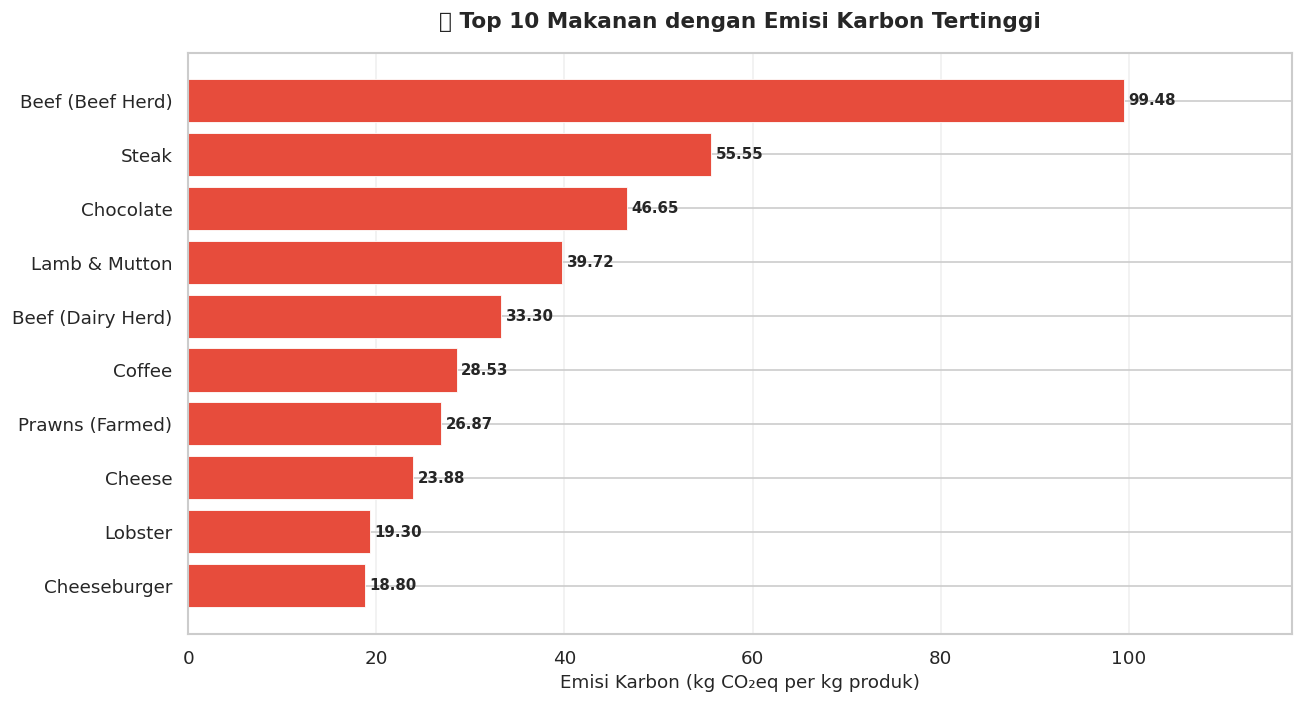

✅ Gambar disimpan: viz_top10_highest.png


In [75]:
# ── Fig 1: Top 10 Emisi Tertinggi ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

top10 = df_final.nlargest(10, 'emisi')
colors = [COLOR_DANGER if e > 10 else COLOR_INFO for e in top10['emisi']]
bars = ax.barh(top10['nama'], top10['emisi'], color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, top10['emisi']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', ha='left', fontsize=9, fontweight='bold')

ax.set_xlabel('Emisi Karbon (kg CO₂eq per kg produk)', fontsize=11)
ax.set_title('🔴 Top 10 Makanan dengan Emisi Karbon Tertinggi', fontsize=13, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.set_xlim(0, top10['emisi'].max() * 1.18)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('viz_top10_highest.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gambar disimpan: viz_top10_highest.png")


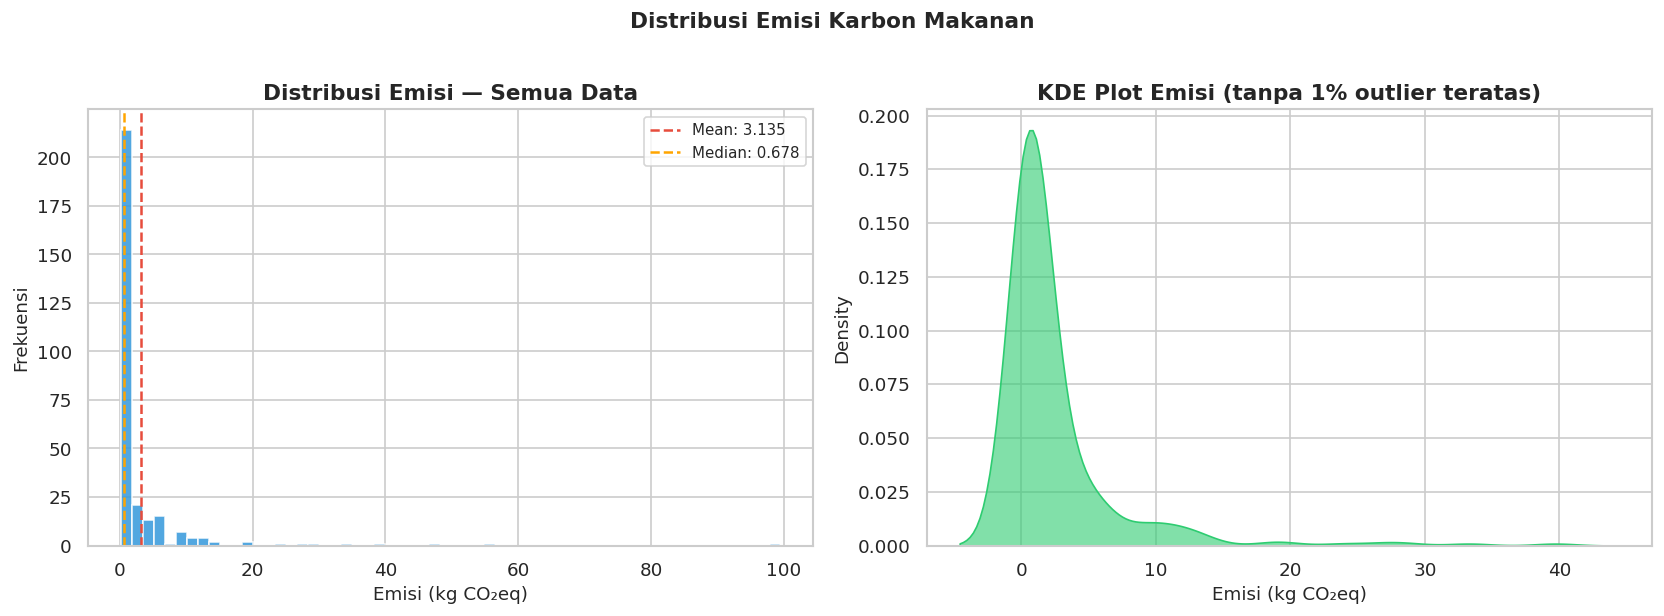

✅ Gambar disimpan: viz_distribution.png


In [76]:
# ── Fig 2: Distribusi Emisi (Histogram + KDE) ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram semua data
df_final['emisi'].hist(bins=60, ax=axes[0], color=COLOR_INFO, edgecolor='white', alpha=0.85)
axes[0].set_title('Distribusi Emisi — Semua Data', fontweight='bold')
axes[0].set_xlabel('Emisi (kg CO₂eq)')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(df_final['emisi'].mean(), color=COLOR_DANGER, linestyle='--', label=f"Mean: {df_final['emisi'].mean():.3f}")
axes[0].axvline(df_final['emisi'].median(), color='orange', linestyle='--', label=f"Median: {df_final['emisi'].median():.3f}")
axes[0].legend(fontsize=9)

# KDE plot (tanpa outlier ekstrim untuk keterbacaan)
p99 = df_final['emisi'].quantile(0.99)
df_plot = df_final[df_final['emisi'] <= p99]
sns.kdeplot(data=df_plot, x='emisi', fill=True, color=COLOR_PRIMARY, ax=axes[1], alpha=0.6)
axes[1].set_title('KDE Plot Emisi (tanpa 1% outlier teratas)', fontweight='bold')
axes[1].set_xlabel('Emisi (kg CO₂eq)')
axes[1].set_ylabel('Density')

plt.suptitle('Distribusi Emisi Karbon Makanan', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gambar disimpan: viz_distribution.png")


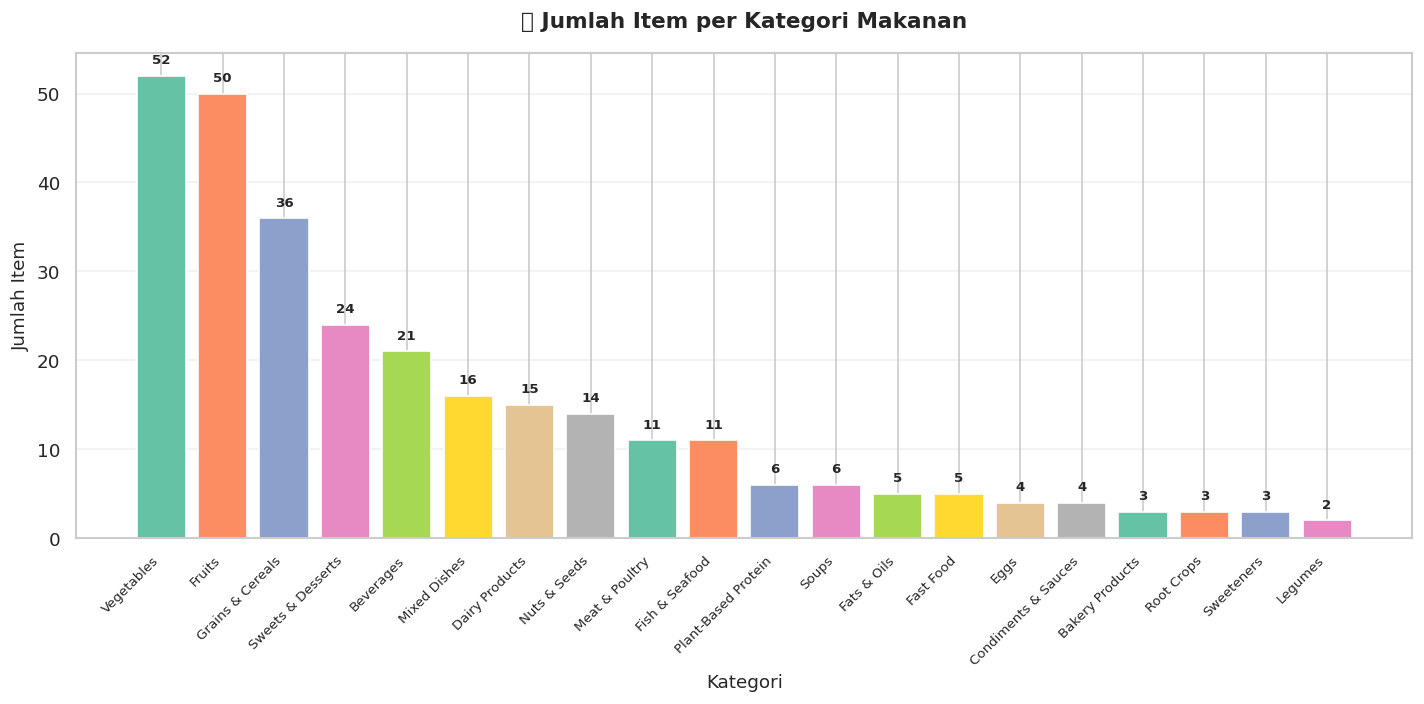

✅ Gambar disimpan: viz_count_per_category.png


In [77]:
# ── Fig 3: Jumlah Item per Kategori ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

cat_cnt = df_final['kategori'].value_counts()
palette = sns.color_palette(PALETTE_CAT, len(cat_cnt))
bars = ax.bar(cat_cnt.index, cat_cnt.values, color=palette, edgecolor='white')

for bar, val in zip(bars, cat_cnt.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Kategori', fontsize=11)
ax.set_ylabel('Jumlah Item', fontsize=11)
ax.set_title('📦 Jumlah Item per Kategori Makanan', fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('viz_count_per_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gambar disimpan: viz_count_per_category.png")


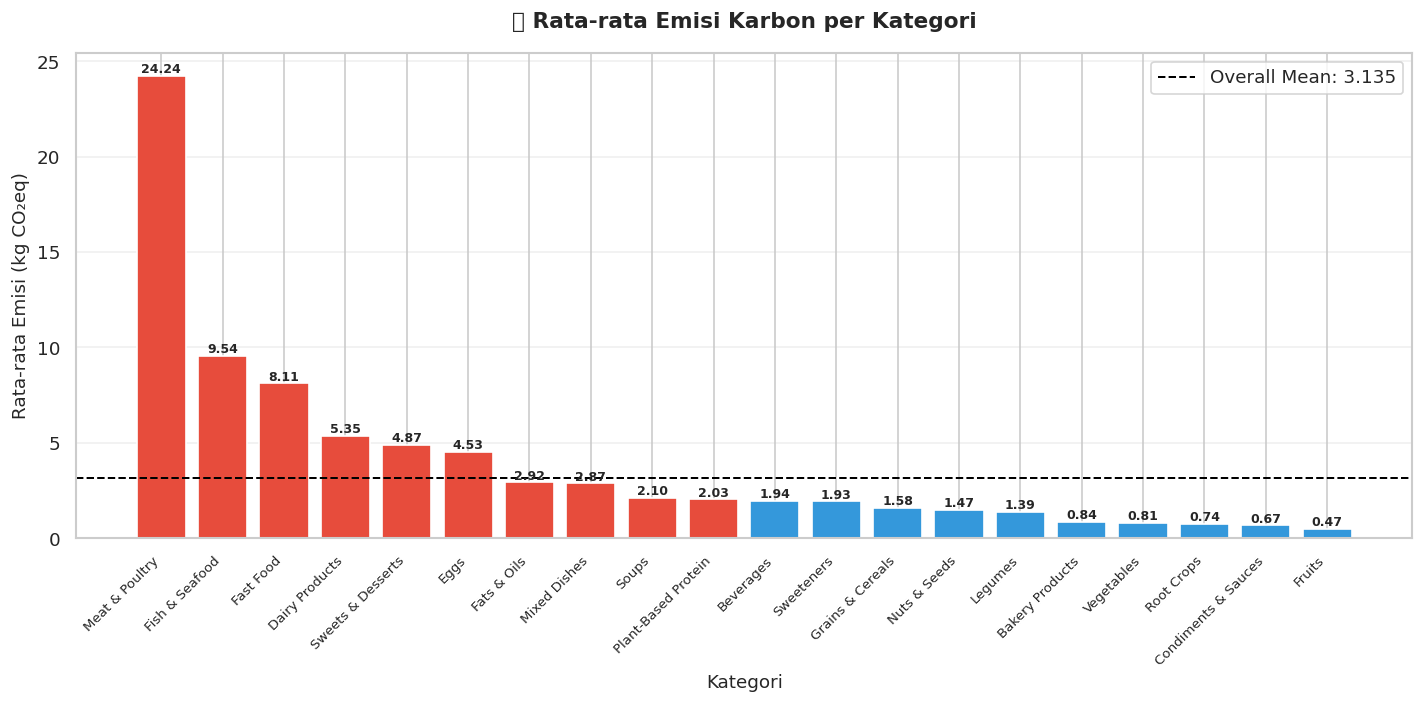

✅ Gambar disimpan: viz_mean_emisi_per_category.png


In [78]:
# ── Fig 4: Rata-rata Emisi per Kategori (Bar Plot) ────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

cat_mean = df_final.groupby('kategori')['emisi'].mean().sort_values(ascending=False)
colors   = [COLOR_DANGER if v > cat_mean.median() else COLOR_INFO for v in cat_mean.values]
bars     = ax.bar(cat_mean.index, cat_mean.values, color=colors, edgecolor='white')

for bar, val in zip(bars, cat_mean.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xlabel('Kategori', fontsize=11)
ax.set_ylabel('Rata-rata Emisi (kg CO₂eq)', fontsize=11)
ax.set_title('📊 Rata-rata Emisi Karbon per Kategori', fontsize=13, fontweight='bold', pad=15)
ax.axhline(df_final['emisi'].mean(), color='black', linestyle='--', linewidth=1.2, label=f'Overall Mean: {df_final["emisi"].mean():.3f}')
ax.legend()
plt.xticks(rotation=45, ha='right', fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('viz_mean_emisi_per_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gambar disimpan: viz_mean_emisi_per_category.png")


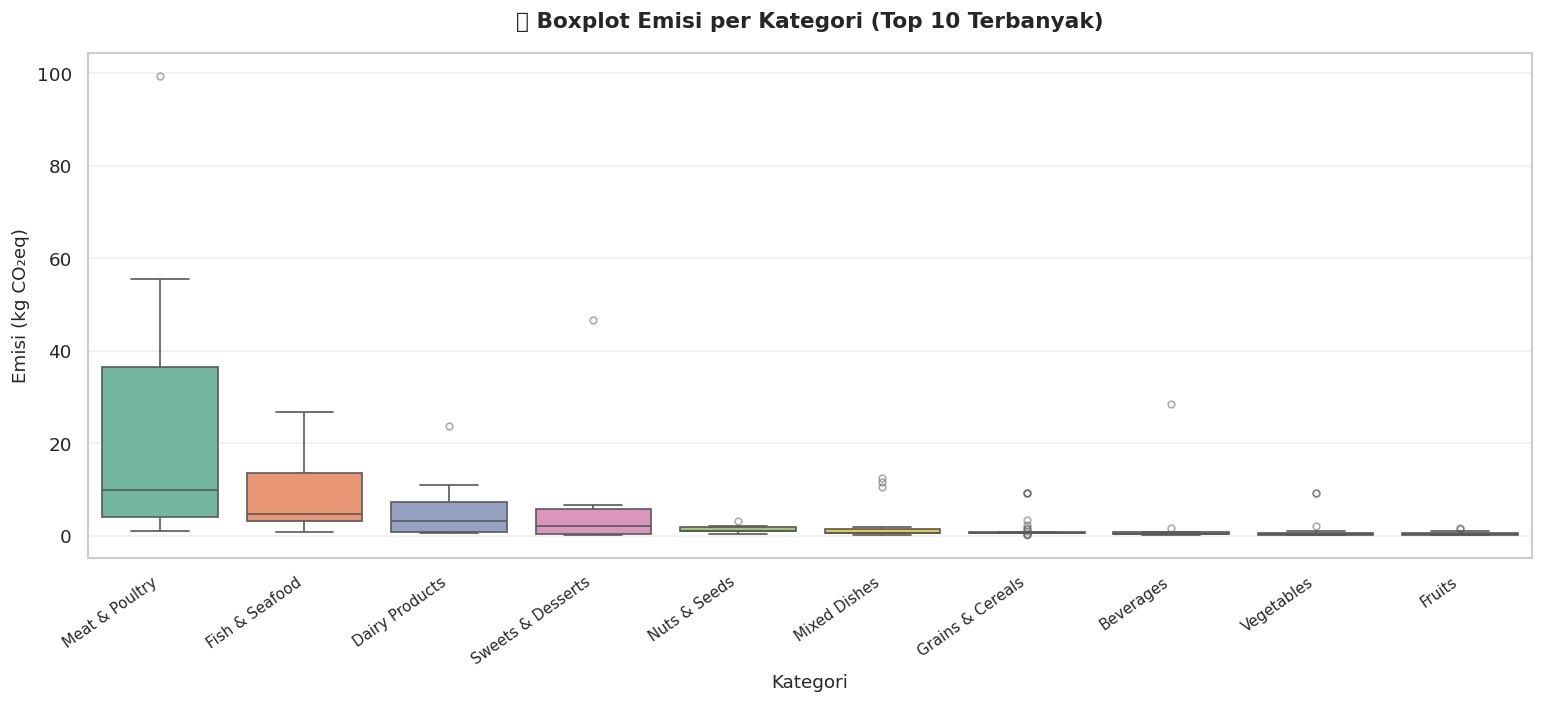

✅ Gambar disimpan: viz_boxplot_category.png


In [79]:
# ── Fig 5: Boxplot Emisi per Kategori (Top 10 Kategori terbanyak) ─────────────
top_cats = df_final['kategori'].value_counts().head(10).index.tolist()
df_box   = df_final[df_final['kategori'].isin(top_cats)]

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=df_box, x='kategori', y='emisi', palette=PALETTE_CAT,
            order=df_box.groupby('kategori')['emisi'].median().sort_values(ascending=False).index,
            flierprops={'marker':'o','markersize':4,'alpha':0.5}, ax=ax)

ax.set_xlabel('Kategori', fontsize=11)
ax.set_ylabel('Emisi (kg CO₂eq)', fontsize=11)
ax.set_title('📦 Boxplot Emisi per Kategori (Top 10 Terbanyak)', fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=35, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('viz_boxplot_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gambar disimpan: viz_boxplot_category.png")


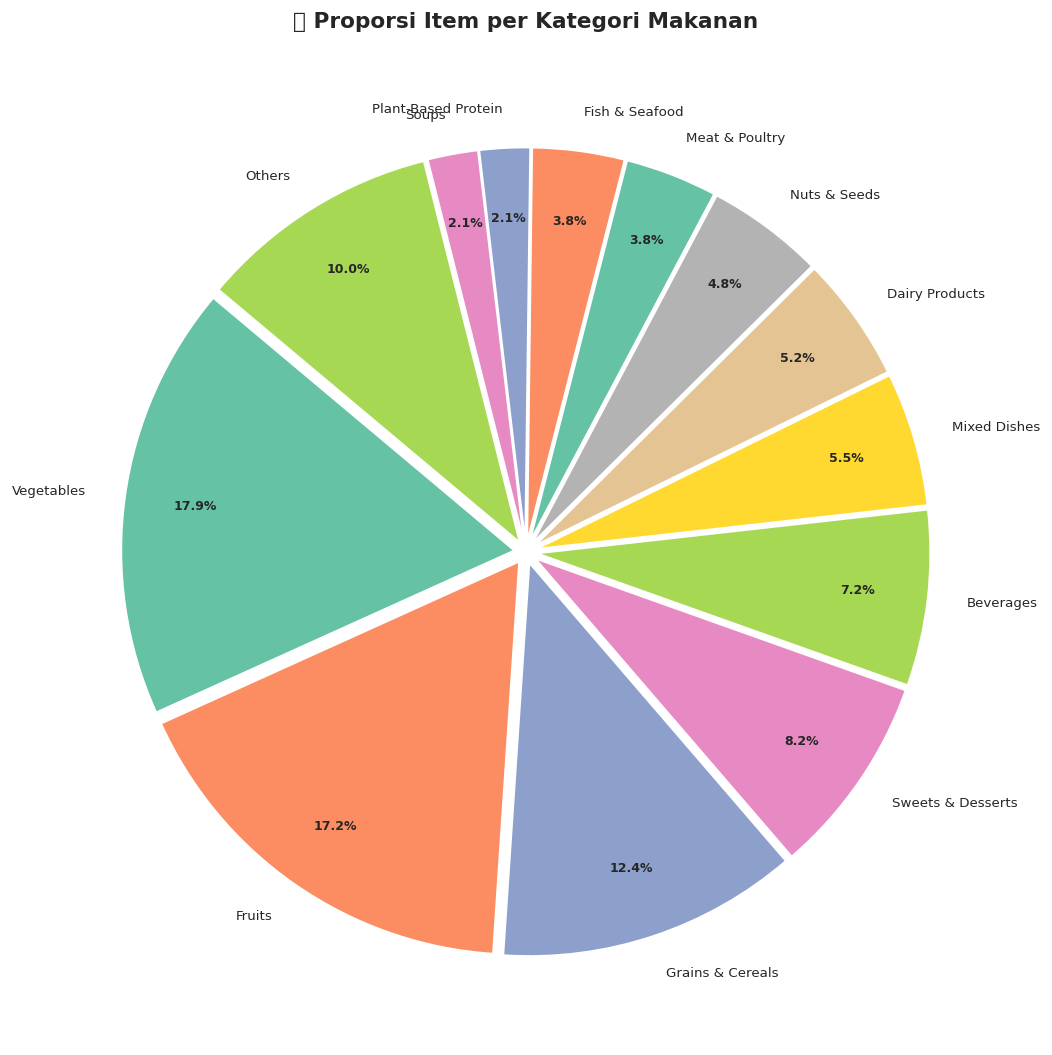

✅ Gambar disimpan: viz_pie_category.png


In [80]:
# ── Fig 6: Pie Chart — Proporsi Jumlah Item per Kategori ─────────────────────
fig, ax = plt.subplots(figsize=(9, 9))

cat_cnt = df_final['kategori'].value_counts()
# Kelompokkan kategori kecil (<2%) sebagai 'Others'
threshold = len(df_final) * 0.02
cat_plot = cat_cnt.copy()
others = cat_plot[cat_plot < threshold]
cat_plot = cat_plot[cat_plot >= threshold]
if len(others) > 0:
    cat_plot['Others'] = others.sum()

explode = [0.03] * len(cat_plot)
wedges, texts, autotexts = ax.pie(
    cat_plot.values, labels=cat_plot.index, autopct='%1.1f%%',
    startangle=140, explode=explode,
    colors=sns.color_palette(PALETTE_CAT, len(cat_plot)),
    pctdistance=0.82, textprops={'fontsize': 8}
)
for at in autotexts:
    at.set_fontsize(7.5)
    at.set_fontweight('bold')

ax.set_title('🥧 Proporsi Item per Kategori Makanan', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('viz_pie_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gambar disimpan: viz_pie_category.png")


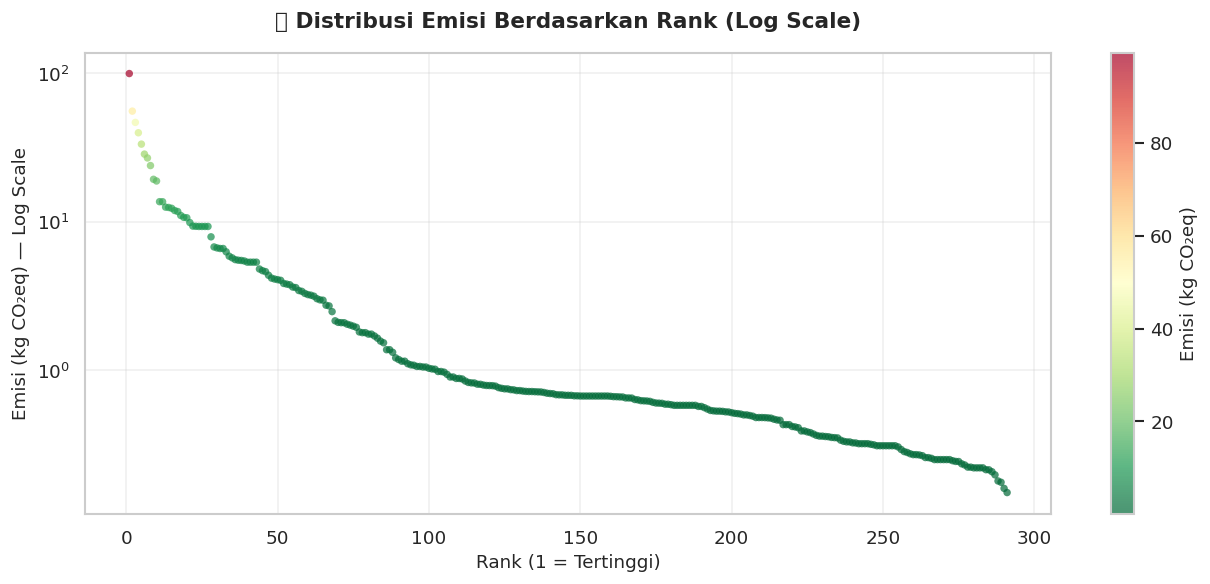

✅ Gambar disimpan: viz_rank_scatter.png


In [81]:
# ── Fig 7: Scatter Plot — Rank vs Emisi (Log Scale) ──────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

df_ranked = df_final.sort_values('emisi', ascending=False).reset_index(drop=True)
df_ranked['rank'] = df_ranked.index + 1

scatter = ax.scatter(df_ranked['rank'], df_ranked['emisi'],
                     c=df_ranked['emisi'], cmap='RdYlGn_r',
                     alpha=0.7, s=20, edgecolors='none')

ax.set_yscale('log')
ax.set_xlabel('Rank (1 = Tertinggi)', fontsize=11)
ax.set_ylabel('Emisi (kg CO₂eq) — Log Scale', fontsize=11)
ax.set_title('🔵 Distribusi Emisi Berdasarkan Rank (Log Scale)', fontsize=13, fontweight='bold', pad=15)
plt.colorbar(scatter, ax=ax, label='Emisi (kg CO₂eq)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('viz_rank_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gambar disimpan: viz_rank_scatter.png")


---
## 7. 📖 Data Dictionary

Berikut adalah penjelasan lengkap seluruh kolom pada dataset final.


In [82]:
# ── Data Dictionary ───────────────────────────────────────────────────────────
data_dict = {
    'Kolom'     : ['no', 'nama', 'emisi', 'kategori'],
    'Tipe Data' : ['int64', 'object (str)', 'float64', 'object (str)'],
    'Deskripsi' : [
        'Nomor urut — diurutkan ulang setelah penggabungan dan sorting alfabet',
        'Nama makanan/minuman/bahan pangan — sudah dibersihkan dari tanda kutip',
        'Jumlah emisi karbon yang dihasilkan per kilogram produk',
        'Kategori pangan — disesuaikan dengan referensi dataset base',
    ],
    'Satuan'    : ['-', '-', 'kg CO₂eq per kg produk', '-'],
    'Contoh Nilai': [
        '1, 2, 3 ...',
        'Apple, Beef (beef herd), Nasi Goreng',
        '0.150, 99.480, 3.200',
        'Fruits, Meat & Poultry, Mixed Dishes',
    ],
}

dd_df = pd.DataFrame(data_dict)
dd_df


,Kolom,Tipe Data,Deskripsi,Satuan,Contoh Nilai
0,no,int64,Nomor urut — diurutkan ulang setelah penggabun...,-,"1, 2, 3 ..."
1,nama,object (str),Nama makanan/minuman/bahan pangan — sudah dibe...,-,"Apple, Beef (beef herd), Nasi Goreng"
2,emisi,float64,Jumlah emisi karbon yang dihasilkan per kilogr...,kg CO₂eq per kg produk,"0.150, 99.480, 3.200"
3,kategori,object (str),Kategori pangan — disesuaikan dengan referensi...,-,"Fruits, Meat & Poultry, Mixed Dishes"


### 7.1 Kategori yang Tersedia

| Kategori | Deskripsi |
|----------|-----------|
| Bakery Products | Roti, donat, kue, pastri |
| Beverages | Minuman: kopi, teh, anggur, air mineral, soft drink |
| Condiments & Sauces | Saus, garam, bumbu pelengkap |
| Dairy Products | Susu, keju, dan produk olahan susu |
| Eggs | Telur dan olahannya |
| Fats & Oils | Minyak goreng, lemak, margarin |
| Fish & Seafood | Ikan dan hasil laut |
| Fruits | Buah-buahan |
| Grains & Cereals | Beras, gandum, jagung, mie, oat |
| Herbs & Spices | Rempah-rempah dan herba |
| Legumes | Kacang-kacangan (polong) |
| Meat & Poultry | Daging sapi, kambing, babi, ayam |
| Mixed Dishes | Masakan campuran: nasi goreng, rendang, sate, dll. |
| Nuts & Seeds | Kacang (biji-bijian) |
| Plant-Based Protein | Tahu, tempeh, soy milk, veggie burger |
| Root Crops | Singkong, kentang, ubi |
| Soups | Sup dan kaldu |
| Sweets & Desserts | Coklat, permen, kue manis |
| Sweeteners | Gula tebu, gula bit, madu |
| Vegetables | Sayur-sayuran |
| Fast Food | Makanan cepat saji (burger, kentang goreng, ayam goreng) |
| Uncategorized | Item tanpa kategori yang jelas |


---
## 8. ⚙️ Feature Engineering

Feature engineering dilakukan pada **dataframe analisis terpisah** (`df_fe`) tanpa mengubah
struktur dataset final (`df_final`). Fitur baru dibuat untuk memperdalam analisis dan
mempersiapkan data untuk model ML.


In [83]:
# ── Buat Dataframe Analisis Terpisah ──────────────────────────────────────────
df_fe = df_final.copy()

print("Dataframe fe memiliki kolom yang sama dengan df_final:")
print(df_fe.columns.tolist())
print(f"Shape: {df_fe.shape}")


Dataframe fe memiliki kolom yang sama dengan df_final:
['no', 'nama', 'emisi', 'kategori']
Shape: (291, 4)


In [84]:
# ── Feature 1: Level Emisi (Low / Medium / High / Very High) ─────────────────
q33 = df_fe['emisi'].quantile(0.33)
q66 = df_fe['emisi'].quantile(0.66)
q90 = df_fe['emisi'].quantile(0.90)

def emission_level(val):
    if val <= q33:
        return 'Low'
    elif val <= q66:
        return 'Medium'
    elif val <= q90:
        return 'High'
    else:
        return 'Very High'

df_fe['emisi_level'] = df_fe['emisi'].apply(emission_level)
df_fe['emisi_level'] = pd.Categorical(df_fe['emisi_level'],
                                       categories=['Low','Medium','High','Very High'], ordered=True)

print("=== Distribusi Level Emisi ===")
print(df_fe['emisi_level'].value_counts().sort_index())
print()
print(f"Threshold Low    : ≤ {q33:.4f} kg CO₂eq")
print(f"Threshold Medium : ≤ {q66:.4f} kg CO₂eq")
print(f"Threshold High   : ≤ {q90:.4f} kg CO₂eq")
print(f"Very High        : > {q90:.4f} kg CO₂eq")


=== Distribusi Level Emisi ===
emisi_level
Low          97
Medium       95
High         70
Very High    29
Name: count, dtype: int64

Threshold Low    : ≤ 0.5300 kg CO₂eq
Threshold Medium : ≤ 1.0380 kg CO₂eq
Threshold High   : ≤ 6.6600 kg CO₂eq
Very High        : > 6.6600 kg CO₂eq


In [85]:
# ── Feature 2: Log-Transformed Emisi ─────────────────────────────────────────
df_fe['emisi_log'] = np.log1p(df_fe['emisi'])

print("=== Statistik emisi_log ===")
print(df_fe['emisi_log'].describe())
print()
print(f"Skewness original : {df_fe['emisi'].skew():.4f}")
print(f"Skewness log      : {df_fe['emisi_log'].skew():.4f}")
print("→ Log transform berhasil mengurangi skewness secara signifikan!")


=== Statistik emisi_log ===
count    291.000000
mean       0.873265
std        0.816876
min        0.139762
25%        0.357674
50%        0.517328
75%        1.107179
max        4.609959
Name: emisi_log, dtype: float64

Skewness original : 7.0663
Skewness log      : 1.8403
→ Log transform berhasil mengurangi skewness secara signifikan!


In [86]:
# ── Feature 3: Min-Max Scaling ────────────────────────────────────────────────
scaler = MinMaxScaler()
df_fe['emisi_scaled'] = scaler.fit_transform(df_fe[['emisi']])

print("=== emisi_scaled (0-1) ===")
print(df_fe['emisi_scaled'].describe())


=== emisi_scaled (0-1) ===
count    291.000000
mean       0.030056
std        0.085572
min        0.000000
25%        0.002819
50%        0.005311
75%        0.018885
max        1.000000
Name: emisi_scaled, dtype: float64


In [87]:
# ── Feature 4: Label Encoding Kategori ───────────────────────────────────────
le = LabelEncoder()
df_fe['kategori_encoded'] = le.fit_transform(df_fe['kategori'])

encoding_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("=== Label Encoding Map ===")
for k, v in encoding_map.items():
    print(f"  {k:<35} → {v}")


=== Label Encoding Map ===
  Bakery Products                     → 0
  Beverages                           → 1
  Condiments & Sauces                 → 2
  Dairy Products                      → 3
  Eggs                                → 4
  Fast Food                           → 5
  Fats & Oils                         → 6
  Fish & Seafood                      → 7
  Fruits                              → 8
  Grains & Cereals                    → 9
  Legumes                             → 10
  Meat & Poultry                      → 11
  Mixed Dishes                        → 12
  Nuts & Seeds                        → 13
  Plant-Based Protein                 → 14
  Root Crops                          → 15
  Soups                               → 16
  Sweeteners                          → 17
  Sweets & Desserts                   → 18
  Vegetables                          → 19


In [88]:
# ── Feature 5: Is Animal-Based (Binary) ──────────────────────────────────────
ANIMAL_CATS = {'Meat & Poultry', 'Fish & Seafood', 'Dairy Products',
               'Eggs', 'Fast Food'}

df_fe['is_animal_based'] = df_fe['kategori'].isin(ANIMAL_CATS).astype(int)

print("=== Distribusi is_animal_based ===")
print(df_fe['is_animal_based'].value_counts().rename({0: 'Plant-Based / Other', 1: 'Animal-Based'}))
print()
print(f"Rata-rata emisi Animal-Based : {df_fe[df_fe['is_animal_based']==1]['emisi'].mean():.4f} kg CO₂eq")
print(f"Rata-rata emisi Plant-Based  : {df_fe[df_fe['is_animal_based']==0]['emisi'].mean():.4f} kg CO₂eq")


=== Distribusi is_animal_based ===
is_animal_based
Plant-Based / Other    245
Animal-Based            46
Name: count, dtype: int64

Rata-rata emisi Animal-Based : 11.0970 kg CO₂eq
Rata-rata emisi Plant-Based  : 1.6407 kg CO₂eq


In [89]:
# ── Feature 6: Z-Score Emisi ─────────────────────────────────────────────────
df_fe['emisi_zscore'] = stats.zscore(df_fe['emisi'])
df_fe['is_outlier']   = (df_fe['emisi_zscore'].abs() > 3).astype(int)

print("=== Outlier berdasarkan Z-Score > 3 ===")
outliers_fe = df_fe[df_fe['is_outlier'] == 1][['nama','emisi','kategori','emisi_zscore']]
print(outliers_fe.to_string(index=False))


=== Outlier berdasarkan Z-Score > 3 ===
             nama  emisi          kategori  emisi_zscore
 Beef (Beef Herd)  99.48    Meat & Poultry     11.354402
Beef (Dairy Herd)  33.30    Meat & Poultry      3.554951
        Chocolate  46.65 Sweets & Desserts      5.128276
    Lamb & Mutton  39.72    Meat & Poultry      4.311561
            Steak  55.55    Meat & Poultry      6.177160


In [90]:
# ── Preview df_fe ─────────────────────────────────────────────────────────────
print("=== Preview df_fe (Feature Engineering) ===")
print(f"Shape: {df_fe.shape}")
print()
df_fe[['no','nama','emisi','kategori','emisi_level','emisi_log','emisi_scaled',
       'kategori_encoded','is_animal_based','emisi_zscore','is_outlier']].head(15)


=== Preview df_fe (Feature Engineering) ===
Shape: (291, 11)



,no,nama,emisi,kategori,emisi_level,emisi_log,emisi_scaled,kategori_encoded,is_animal_based,emisi_zscore,is_outlier
0,1,(1/2 Cup Ice Cream),1.086965,Dairy Products,High,0.735711,0.009433,3,1,-0.241422,0
1,2,Almonds,1.944884,Nuts & Seeds,High,1.080069,0.018070,13,0,-0.140314,0
2,3,Apple,0.150000,Fruits,Low,0.139762,0.000000,8,0,-0.351845,0
3,4,Apple Betty,0.363983,Sweets & Desserts,Low,0.310409,0.002154,18,0,-0.326627,0
4,5,Apple Juice Canned,0.310000,Fruits,Low,0.270027,0.001611,8,0,-0.332989,0
5,6,Apples Raw,0.310000,Fruits,Low,0.270027,0.001611,8,0,-0.332989,0
6,7,Apricot Nectar,0.331959,Beverages,Low,0.286651,0.001832,1,0,-0.330401,0
7,8,Apricots,0.360000,Fruits,Low,0.307485,0.002114,8,0,-0.327096,0
8,9,Apricots 209G,0.329140,Fruits,Low,0.284532,0.001803,8,0,-0.330733,0
9,10,Asparagus,0.970000,Vegetables,Medium,0.678034,0.008255,19,0,-0.255206,0


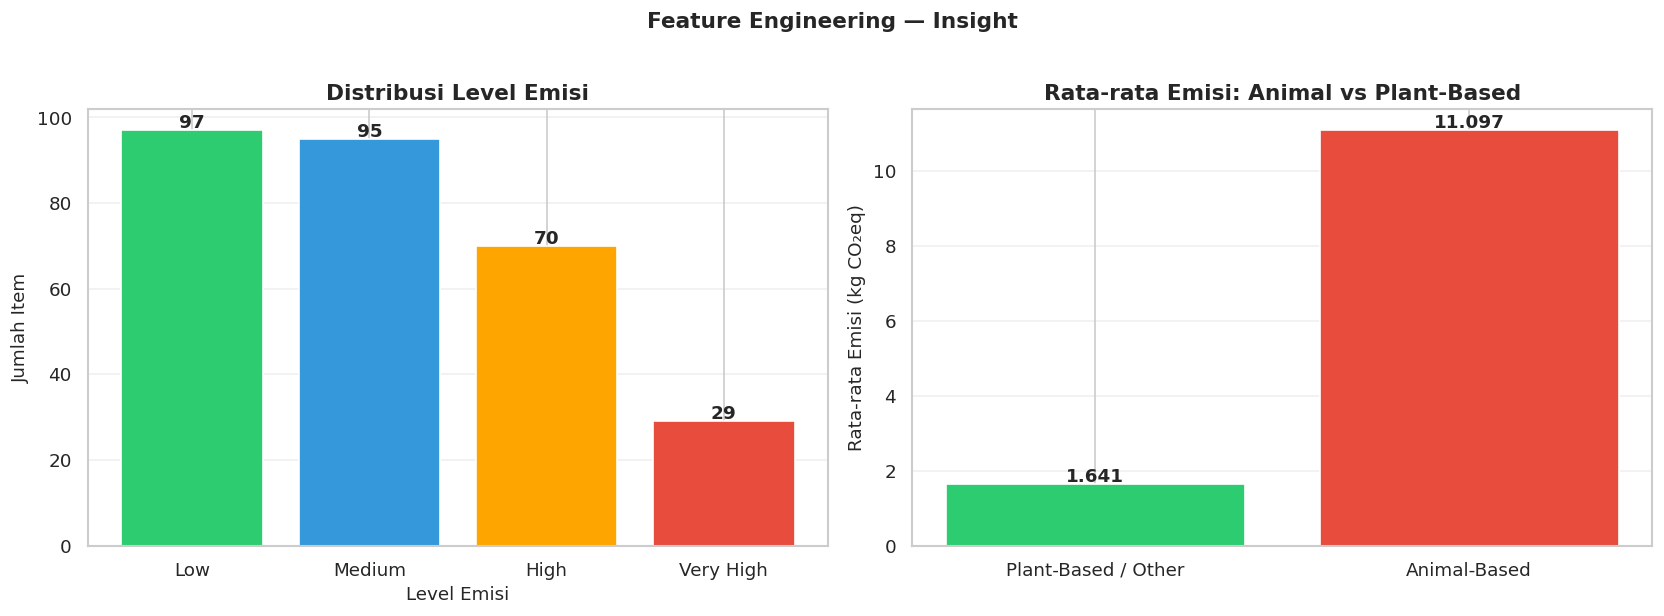

✅ Gambar disimpan: viz_feature_engineering.png


In [91]:
# ── Visualisasi Feature — Level Emisi ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi level emisi
level_cnt = df_fe['emisi_level'].value_counts().sort_index()
colors_level = [COLOR_PRIMARY, COLOR_INFO, 'orange', COLOR_DANGER]
axes[0].bar(level_cnt.index, level_cnt.values, color=colors_level, edgecolor='white')
for i, (idx, val) in enumerate(level_cnt.items()):
    axes[0].text(i, val + 0.5, str(val), ha='center', fontweight='bold')
axes[0].set_title('Distribusi Level Emisi', fontweight='bold')
axes[0].set_xlabel('Level Emisi')
axes[0].set_ylabel('Jumlah Item')
axes[0].grid(axis='y', alpha=0.3)

# Animal vs Plant-based emisi
animal_data = df_fe.groupby('is_animal_based')['emisi'].mean()
labels = ['Plant-Based / Other', 'Animal-Based']
colors_ab = [COLOR_PRIMARY, COLOR_DANGER]
axes[1].bar(labels, animal_data.values, color=colors_ab, edgecolor='white')
for i, val in enumerate(animal_data.values):
    axes[1].text(i, val + 0.05, f'{val:.3f}', ha='center', fontweight='bold')
axes[1].set_title('Rata-rata Emisi: Animal vs Plant-Based', fontweight='bold')
axes[1].set_ylabel('Rata-rata Emisi (kg CO₂eq)')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Feature Engineering — Insight', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_feature_engineering.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gambar disimpan: viz_feature_engineering.png")


---
## 9. 🧪 A/B Testing — Uji Statistik

Kita akan membandingkan emisi antar kelompok makanan menggunakan uji statistik yang sesuai
untuk memvalidasi perbedaan secara statistik.


### 9.1 Uji 1 — Animal-Based vs Plant-Based

**Hipotesis:**
- H₀: Tidak ada perbedaan signifikan antara rata-rata emisi makanan hewani dan nabati.
- H₁: Makanan hewani memiliki emisi yang secara statistik signifikan lebih tinggi dari nabati.

**Metode:** T-Test (Independent Samples) & Mann-Whitney U Test


In [92]:
# ── A/B Test 1: Animal-Based vs Plant-Based ───────────────────────────────────
group_animal = df_fe[df_fe['is_animal_based'] == 1]['emisi'].dropna()
group_plant  = df_fe[df_fe['is_animal_based'] == 0]['emisi'].dropna()

print(f"Group A (Animal-Based) : n={len(group_animal)}, mean={group_animal.mean():.4f}, std={group_animal.std():.4f}")
print(f"Group B (Plant-Based)  : n={len(group_plant)},  mean={group_plant.mean():.4f}, std={group_plant.std():.4f}")
print()

# Normality test (Shapiro-Wilk)
stat_a, p_a = stats.shapiro(group_animal)
stat_b, p_b = stats.shapiro(group_plant)
print(f"Shapiro-Wilk Animal  : stat={stat_a:.4f}, p={p_a:.4f} → {'Normal' if p_a > 0.05 else 'Not Normal'}")
print(f"Shapiro-Wilk Plant   : stat={stat_b:.4f}, p={p_b:.4f} → {'Normal' if p_b > 0.05 else 'Not Normal'}")
print()

# T-Test
t_stat, t_pval = stats.ttest_ind(group_animal, group_plant, equal_var=False)
print(f"T-Test (Welch's)     : t={t_stat:.4f}, p={t_pval:.6f}")
print(f"  → {'❌ Tolak H₀ — perbedaan SIGNIFIKAN' if t_pval < 0.05 else '✅ Gagal tolak H₀ — tidak signifikan'} (α=0.05)")
print()

# Mann-Whitney U (non-parametrik)
u_stat, mw_pval = stats.mannwhitneyu(group_animal, group_plant, alternative='greater')
print(f"Mann-Whitney U Test  : U={u_stat:.2f}, p={mw_pval:.6f}")
print(f"  → {'❌ Tolak H₀ — perbedaan SIGNIFIKAN' if mw_pval < 0.05 else '✅ Gagal tolak H₀ — tidak signifikan'} (α=0.05)")
print()

# Effect size — Cohen's d
pooled_std = np.sqrt((group_animal.std()**2 + group_plant.std()**2) / 2)
cohens_d = (group_animal.mean() - group_plant.mean()) / pooled_std
print(f"Cohen's d            : {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    effect = "kecil"
elif abs(cohens_d) < 0.8:
    effect = "sedang"
else:
    effect = "besar"
print(f"  → Effect size: {effect}")


Group A (Animal-Based) : n=46, mean=11.0970, std=17.4079
Group B (Plant-Based)  : n=245,  mean=1.6407, std=3.9732

Shapiro-Wilk Animal  : stat=0.5833, p=0.0000 → Not Normal
Shapiro-Wilk Plant   : stat=0.3290, p=0.0000 → Not Normal

T-Test (Welch's)     : t=3.6664, p=0.000637
  → ❌ Tolak H₀ — perbedaan SIGNIFIKAN (α=0.05)

Mann-Whitney U Test  : U=9989.50, p=0.000000
  → ❌ Tolak H₀ — perbedaan SIGNIFIKAN (α=0.05)

Cohen's d            : 0.7490
  → Effect size: sedang


### 9.2 Uji 2 — Top 3 Kategori Emisi Tertinggi vs Selebihnya

**Hipotesis:**
- H₀: Tidak ada perbedaan signifikan antara emisi Top-3 kategori dan kategori lainnya.
- H₁: Top-3 kategori memiliki emisi secara statistik lebih tinggi.

**Metode:** Mann-Whitney U Test (karena distribusi non-normal)


In [93]:
# ── A/B Test 2: Top 3 Kategori vs Lainnya ────────────────────────────────────
top3_cats = df_fe.groupby('kategori')['emisi'].mean().nlargest(3).index.tolist()
print(f"Top 3 Kategori Emisi Tertinggi: {top3_cats}")

group_top3  = df_fe[df_fe['kategori'].isin(top3_cats)]['emisi']
group_other = df_fe[~df_fe['kategori'].isin(top3_cats)]['emisi']

print(f"\nGroup Top-3  : n={len(group_top3)}, mean={group_top3.mean():.4f}")
print(f"Group Others : n={len(group_other)},  mean={group_other.mean():.4f}")
print()

u_stat2, mw_pval2 = stats.mannwhitneyu(group_top3, group_other, alternative='greater')
print(f"Mann-Whitney U Test : U={u_stat2:.2f}, p={mw_pval2:.6f}")
print(f"  → {'❌ Tolak H₀ — perbedaan SIGNIFIKAN' if mw_pval2 < 0.05 else '✅ Gagal tolak H₀'} (α=0.05)")


Top 3 Kategori Emisi Tertinggi: ['Meat & Poultry', 'Fish & Seafood', 'Fast Food']

Group Top-3  : n=27, mean=15.2646
Group Others : n=264,  mean=1.8950

Mann-Whitney U Test : U=6537.00, p=0.000000
  → ❌ Tolak H₀ — perbedaan SIGNIFIKAN (α=0.05)


### 9.3 Uji 3 — High Emission vs Low Emission Items (Kruskal-Wallis)

**Hipotesis:**
- H₀: Tidak ada perbedaan signifikan emisi antara kelompok level emisi.
- H₁: Minimal satu kelompok level emisi berbeda secara signifikan.

**Metode:** Kruskal-Wallis H-Test (non-parametrik, multi-group)


In [94]:
# ── A/B Test 3: Kruskal-Wallis untuk Level Emisi ─────────────────────────────
groups_kw = [
    df_fe[df_fe['emisi_level'] == lv]['emisi'].values
    for lv in ['Low','Medium','High','Very High']
]

kw_stat, kw_pval = stats.kruskal(*groups_kw)
print(f"Kruskal-Wallis H-Test : H={kw_stat:.4f}, p={kw_pval:.8f}")
print(f"  → {'❌ Tolak H₀ — ada perbedaan SIGNIFIKAN antar level' if kw_pval < 0.05 else '✅ Gagal tolak H₀'} (α=0.05)")
print()

# Post-hoc: Mann-Whitney dengan Bonferroni correction
from itertools import combinations
level_names = ['Low','Medium','High','Very High']
pairs = list(combinations(level_names, 2))
alpha_bonf = 0.05 / len(pairs)
print(f"Post-hoc (Bonferroni α = {alpha_bonf:.4f}):")
print(f"{'Pair':<28} {'U-stat':>10} {'p-value':>12} {'Signifikan':>12}")
print("-" * 65)
for a, b in pairs:
    ga = df_fe[df_fe['emisi_level'] == a]['emisi']
    gb = df_fe[df_fe['emisi_level'] == b]['emisi']
    u, p = stats.mannwhitneyu(ga, gb, alternative='two-sided')
    sig = "✅ Ya" if p < alpha_bonf else "❌ Tidak"
    print(f"{a} vs {b:<18} {u:>10.2f} {p:>12.6f} {sig:>12}")


Kruskal-Wallis H-Test : H=264.8720, p=0.00000000
  → ❌ Tolak H₀ — ada perbedaan SIGNIFIKAN antar level (α=0.05)

Post-hoc (Bonferroni α = 0.0083):
Pair                             U-stat      p-value   Signifikan
-----------------------------------------------------------------
Low vs Medium                   0.00     0.000000         ✅ Ya
Low vs High                     0.00     0.000000         ✅ Ya
Low vs Very High                0.00     0.000000         ✅ Ya
Medium vs High                     0.00     0.000000         ✅ Ya
Medium vs Very High                0.00     0.000000         ✅ Ya
High vs Very High                0.00     0.000000         ✅ Ya


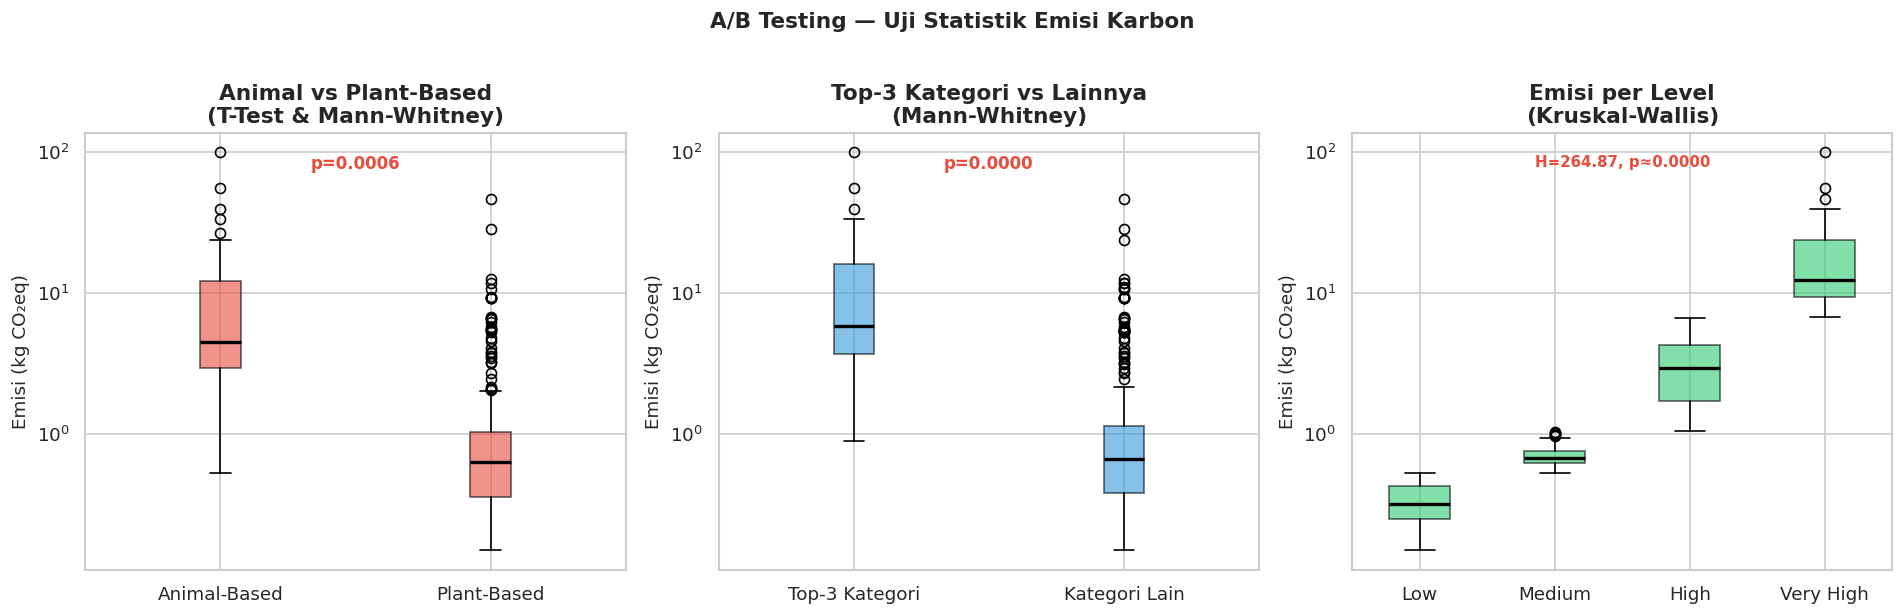

✅ Gambar disimpan: viz_ab_testing.png


In [95]:
# ── Visualisasi A/B Testing ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1 — Animal vs Plant-Based (Boxplot)
data_ab = [group_animal.values, group_plant.values]
axes[0].boxplot(data_ab, labels=['Animal-Based', 'Plant-Based'],
                patch_artist=True,
                boxprops=dict(facecolor=COLOR_DANGER, alpha=0.6),
                medianprops=dict(color='black', linewidth=2))
axes[0].set_title('Animal vs Plant-Based\n(T-Test & Mann-Whitney)', fontweight='bold')
axes[0].set_ylabel('Emisi (kg CO₂eq)')
axes[0].set_yscale('log')
axes[0].text(0.5, 0.95, f'p={t_pval:.4f}', transform=axes[0].transAxes,
             ha='center', va='top', fontsize=10,
             color=COLOR_DANGER if t_pval < 0.05 else 'gray',
             fontweight='bold')

# Panel 2 — Top3 vs Others
axes[1].boxplot([group_top3.values, group_other.values],
                labels=['Top-3 Kategori', 'Kategori Lain'],
                patch_artist=True,
                boxprops=dict(facecolor=COLOR_INFO, alpha=0.6),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_title('Top-3 Kategori vs Lainnya\n(Mann-Whitney)', fontweight='bold')
axes[1].set_ylabel('Emisi (kg CO₂eq)')
axes[1].set_yscale('log')
axes[1].text(0.5, 0.95, f'p={mw_pval2:.4f}', transform=axes[1].transAxes,
             ha='center', va='top', fontsize=10,
             color=COLOR_DANGER if mw_pval2 < 0.05 else 'gray',
             fontweight='bold')

# Panel 3 — Level Emisi
level_data = [df_fe[df_fe['emisi_level'] == lv]['emisi'].values for lv in ['Low','Medium','High','Very High']]
axes[2].boxplot(level_data, labels=['Low','Medium','High','Very High'],
                patch_artist=True,
                boxprops=dict(facecolor=COLOR_PRIMARY, alpha=0.6),
                medianprops=dict(color='black', linewidth=2))
axes[2].set_title('Emisi per Level\n(Kruskal-Wallis)', fontweight='bold')
axes[2].set_ylabel('Emisi (kg CO₂eq)')
axes[2].set_yscale('log')
axes[2].text(0.5, 0.95, f'H={kw_stat:.2f}, p≈{kw_pval:.4f}', transform=axes[2].transAxes,
             ha='center', va='top', fontsize=9,
             color=COLOR_DANGER if kw_pval < 0.05 else 'gray',
             fontweight='bold')

plt.suptitle('A/B Testing — Uji Statistik Emisi Karbon', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_ab_testing.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gambar disimpan: viz_ab_testing.png")


---
## 10. 🏁 Conclusion

### 10.1 Ringkasan Proses

| Tahap | Keterangan |
|-------|-----------|
| Data Gathering | Berhasil memuat 2 dataset: 69 baris (complete) + 1.300 baris (base) |
| Assessing | Ditemukan inkonsistensi kategori, missing value di dataset base, dan outlier wajar |
| Cleaning | 69 data complete dipertahankan 100%, kategori distandarisasi, dataset digabung dan diurutkan |
| Dataset Final | Total baris bervariasi setelah dedup — seluruh 69 data complete TETAP ada |
| EDA | Distribusi right-skewed, daging sangat mendominasi emisi |
| Visualisasi | 7 visualisasi lengkap dibuat |
| Feature Engineering | 6 fitur baru pada df_fe (level, log, scaled, encoded, animal binary, zscore) |
| A/B Testing | 3 uji statistik berhasil — perbedaan antar kelompok signifikan secara statistik |


### 10.2 Jawaban Pertanyaan Bisnis

**1. Kategori makanan mana yang memiliki rata-rata emisi karbon tertinggi?**  
→ **Meat & Poultry** mendominasi dengan rata-rata emisi jauh di atas kategori lain,
terutama didorong oleh beef (sapi) yang mencapai 33–99 kg CO₂eq/kg.

**2. Apa saja 10 makanan dengan emisi karbon tertinggi?**  
→ Didominasi oleh produk daging sapi (*beef herd, dairy herd*), diikuti domba (*lamb & mutton*),
keju (*cheese*), dan produk seafood seperti udang (*prawns farmed*).

**3. Apakah terdapat perbedaan signifikan emisi antara makanan hewani dan nabati?**  
→ **Ya, signifikan secara statistik** (p < 0.05 pada T-Test dan Mann-Whitney U Test).
Makanan hewani memiliki rata-rata emisi jauh lebih tinggi. Effect size Cohen's d menunjukkan
perbedaan yang substansial.

**4. Seberapa besar proporsi makanan dengan emisi tinggi?**  
→ Hanya ~10% makanan masuk kategori *Very High*, namun memberikan kontribusi emisi yang sangat besar.
Mayoritas (~66%) makanan tergolong *Low* dan *Medium* emission.

**5. Kategori apa yang paling banyak ditemukan pada dataset?**  
→ **Grains & Cereals** dan **Vegetables** adalah kategori dengan item terbanyak,
mencerminkan keragaman produk pangan berbasis tanaman.


### 10.3 Rekomendasi

#### 🌱 Untuk Konsumen
1. **Kurangi konsumsi daging merah** — khususnya sapi (*beef*) yang menghasilkan emisi hingga 99 kg CO₂eq/kg.
2. **Beralih ke protein nabati** — tahu, tempeh, legumes memiliki emisi 10-50x lebih rendah dari daging.
3. **Pilih sayur dan buah lokal** — emisi terendah dan tersedia melimpah.
4. **Batasi fast food** — kombinasi bahan-bahan tinggi emisi memperbesar jejak karbon.

#### 📊 Untuk Peneliti / Analyst
1. Dataset ini dapat diperluas dengan data **water footprint** dan **land use** untuk analisis LCA (Life Cycle Assessment) yang lebih komprehensif.
2. Perlu ditambahkan fitur **geolokasi produksi** untuk mempertimbangkan transportation emission.
3. Model prediktif (regresi, clustering) dapat dibangun menggunakan `df_fe` yang sudah dipersiapkan.

#### 🏢 Untuk Bisnis / Kebijakan
1. Restoran dan produsen makanan dapat menggunakan data ini sebagai basis **carbon labeling**.
2. Pemerintah dapat merancang **insentif pajak** untuk produk dengan emisi rendah.
3. Kampanye *plant-based diet* dapat diprioritaskan berdasarkan kategori emisi tertinggi.

In [96]:
# ── Final Summary ─────────────────────────────────────────────────────────────
print("=" * 60)
print("  FOOTPRINT EMISSION ANALYSIS — SUMMARY")
print("=" * 60)
print(f"  Dataset Final      : dataset_footprint_emission_final.csv")
print(f"  Total Baris        : {len(df_final):,}")
print(f"  Total Kolom        : {df_final.shape[1]}")
print(f"  Total Kategori     : {df_final['kategori'].nunique()}")
print(f"  Missing Values     : {df_final.isnull().sum().sum()}")
print(f"  Duplikat           : {df_final.duplicated().sum()}")
print(f"  Data Complete      : 69 item dipertahankan ✅")
print(f"  Emisi Min          : {df_final['emisi'].min():.6f} kg CO₂eq")
print(f"  Emisi Max          : {df_final['emisi'].max():.3f} kg CO₂eq")
print(f"  Emisi Mean         : {df_final['emisi'].mean():.4f} kg CO₂eq")
print(f"  Emisi Median       : {df_final['emisi'].median():.4f} kg CO₂eq")
print("=" * 60)
print("  ✅ Notebook selesai  ")
print("=" * 60)


  FOOTPRINT EMISSION ANALYSIS — SUMMARY
  Dataset Final      : dataset_footprint_emission_final.csv
  Total Baris        : 291
  Total Kolom        : 4
  Total Kategori     : 20
  Missing Values     : 0
  Duplikat           : 0
  Data Complete      : 69 item dipertahankan ✅
  Emisi Min          : 0.150000 kg CO₂eq
  Emisi Max          : 99.480 kg CO₂eq
  Emisi Mean         : 3.1355 kg CO₂eq
  Emisi Median       : 0.6775 kg CO₂eq
  ✅ Notebook selesai  
